# Low-mid load sweep (u32): LLM-LA (mine) vs BooM — head-to-head

Comparison of the **low-mid load point** (32 users x 4 convs = 128 conversations)
across all seven strategies, running the *same* CodeFlowBench workload under identical harness code.
All seven cells (mine 132-135 + BooM 136-138) ran back-to-back in the same load sweep, so this is
an apples-to-apples u32 comparison with BooM's KV-cache prefix matching enabled.

| exp | side | strategy | path |
|----|------|----------|------|
| 132 | **mine** | both (kv+len+affinity, hard) | us + LLM-LA router (`pull`) |
| 133 | **mine** | affinity hard | us + LLM-LA router (`pull`) |
| 134 | **mine** | affinity soft | us + LLM-LA router (`pull`) |
| 135 | **mine** | prefix only | us + LLM-LA router (`pull`) |
| 136 | boom | round_robin | BooM direct |
| 137 | boom | key_affinity (`key_affinity_keys=32`) | BooM direct |
| 138 | boom | kvc_aware | BooM direct |

**Data-quality notes (why we compute from raw, not the summaries):**
- Per-turn Claude log is `claude_client_logs.json` for *mine* and `logs.json` for *boom* — same schema.
- `cache_read_input_tokens` / `cache_creation_input_tokens` are **0** (Anthropic caching is not reported through the local vLLM path) -> not a usable KV signal here.
- `metrics_summary.json` engine `prefix_cache_hit_rate` came back zero/empty -> **ignored**; fleet stats are recomputed from `metrics.jsonl` per-pod samples, and true engine TTFT/prefix-hit are backfilled from Prometheus (S2e).
- Router-level `kv_hit` exists only for *mine* (BooM direct has no router log). We surface it as mine-only routing detail.
- All 7 cells processed the **same 128-conversation workload**, so per-turn latency is directly comparable; the wall-clock **makespan** to clear it is itself a headline metric.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments"

# exp -> (side, strategy). Order defines plot order.
# LOW-MID point (u32): mine = 132-135, boom = 136-138.
REGISTRY = {
    132: ("mine", "both+hard"),
    133: ("mine", "aff-hard"),
    134: ("mine", "aff-soft"),
    135: ("mine", "prefix"),
    136: ("boom", "rr"),
    137: ("boom", "key_aff"),
    138: ("boom", "kvc"),
}
EXP_IDS = [e for e in REGISTRY if (Path(EXPERIMENTS_ROOT) / str(e)).is_dir()]

def side(e):   return REGISTRY[e][0]
def strat(e):  return REGISTRY[e][1]
def label(e):  return f"{e}:{side(e)}/{strat(e)}"
LABELS = {e: label(e) for e in EXP_IDS}

# blue family = mine, warm family = boom
_MINE = ["#1f4e8c", "#2b6cb0", "#4C78A8", "#7fa8d0"]
_BOOM = ["#B4413C", "#E45756", "#F58518"]
def color(e):
    if side(e) == "mine":
        return _MINE[[x for x in EXP_IDS if side(x) == "mine"].index(e) % len(_MINE)]
    return _BOOM[[x for x in EXP_IDS if side(x) == "boom"].index(e) % len(_BOOM)]
COLORS = {e: color(e) for e in EXP_IDS}

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

def exp_dir(e): return Path(EXPERIMENTS_ROOT) / str(e)

def _read_json(p):
    p = Path(p)
    return json.load(p.open()) if p.is_file() else None

def _read_ndjson(p):
    p = Path(p); rows = []
    if not p.is_file():
        return rows
    for line in p.open("r", encoding="utf-8"):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass
    return rows

def turns_path(e):
    """Per-turn Claude log: mine -> claude_client_logs.json, boom -> logs.json."""
    p = exp_dir(e) / "claude_client_logs.json"
    return p if p.is_file() else (exp_dir(e) / "logs.json")

def bar_by_exp(values, title, ylabel, fmt="{:.1f}", figsize=(11, 4), rot=25):
    xs = [e for e in EXP_IDS if e in values and pd.notna(values[e])]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(range(len(xs)), [values[e] for e in xs],
           color=[COLORS[e] for e in xs], edgecolor="black")
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([LABELS[e] for e in xs], rotation=rot, ha="right", fontsize=8)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=.3)
    for i, e in enumerate(xs):
        ax.text(i, values[e], fmt.format(values[e]), ha="center", va="bottom", fontsize=7)
    ax.legend(handles=[Patch(color="#4C78A8", label="mine (LLM-LA router)"),
                       Patch(color="#E45756", label="boom (direct)")], fontsize=8)
    plt.tight_layout(); plt.show()

print("cells found:", EXP_IDS)

cells found: [132, 133, 134, 135, 136, 137, 138]


## 1. Registry & workload
Deployed settings, turns processed, and wall-clock makespan per cell.

In [2]:
def load_meta(e):
    rs = _read_json(exp_dir(e) / "run_summary.json") or {}
    tp = turns_path(e)
    n_turns = sum(1 for _ in _read_ndjson(tp))
    u = rs.get("users") or {}
    return {
        "exp": e, "side": side(e), "strategy": strat(e), "label": LABELS[e],
        "turns": n_turns,
        "num_users": u.get("num_users"),
        "convs_per_user": u.get("convs_per_user"),
        "wall_s": rs.get("wall_time_s"),
        "load_s": rs.get("load_runner_duration_s"),
        "total_requests": rs.get("total_requests"),
        "turn_src": tp.name,
    }

REG = pd.DataFrame([load_meta(e) for e in EXP_IDS]).set_index("exp")
REG["wall_min"] = (REG["wall_s"] / 60).round(1)
REG["load_min"] = (REG["load_s"] / 60).round(1)
display(REG[["side", "strategy", "label", "num_users", "convs_per_user", "turns",
             "load_min", "wall_min", "total_requests", "turn_src"]])

,side,strategy,label,num_users,convs_per_user,turns,load_min,wall_min,total_requests,turn_src
exp,,,,,,,,,,
132,mine,both+hard,132:mine/both+hard,32,4,453,263.4,270.4,128,claude_client_logs.json
133,mine,aff-hard,133:mine/aff-hard,32,4,450,193.8,201.3,128,claude_client_logs.json
134,mine,aff-soft,134:mine/aff-soft,32,4,446,238.5,245.0,128,claude_client_logs.json
135,mine,prefix,135:mine/prefix,32,4,449,234.6,241.4,128,claude_client_logs.json
136,boom,rr,136:boom/rr,32,4,452,250.5,250.5,128,logs.json
137,boom,key_aff,137:boom/key_aff,32,4,450,280.9,280.9,128,logs.json
138,boom,kvc,138:boom/kvc,32,4,452,187.7,187.7,128,logs.json


## 2. Per-turn latency (headline)
End-to-end wall time per Claude turn (`end_to_end_s`) and server API time (`api_ms`).
All cells ran the same 128-conversation workload, so these percentiles are directly comparable.

In [3]:
def load_turns(e):
    df = pd.DataFrame(_read_ndjson(turns_path(e)))
    if df.empty:
        return df
    for c in ["prompt_tokens", "completion_tokens", "end_to_end_s", "api_ms",
              "duration_ms", "cache_read_input_tokens", "cache_creation_input_tokens",
              "conversation_id", "user_id", "turn_idx", "num_turns"]:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["exp"] = e; df["side"] = side(e); df["strategy"] = strat(e); df["label"] = LABELS[e]
    df["api_s"] = df["api_ms"] / 1000.0
    df = df.sort_values(["user_id", "conversation_id", "turn_idx"])
    df["turn_type"] = np.where(df["turn_idx"].fillna(0) == 0, "first", "repeat")
    return df

TURNS = pd.concat([load_turns(e) for e in EXP_IDS], ignore_index=True)

def pctl_table(df, col):
    g = df.groupby("exp")[col]
    out = pd.DataFrame({
        "n": g.size(),
        "mean": g.mean(),
        "p50": g.quantile(.50),
        "p90": g.quantile(.90),
        "p95": g.quantile(.95),
        "p99": g.quantile(.99),
        "max": g.max(),
    })
    out.index = [LABELS[e] for e in out.index]
    return out

print("=== end_to_end_s (per turn) ===")
LAT = pctl_table(TURNS, "end_to_end_s")
display(LAT.round(2))
print("=== api_s (server time per turn) ===")
display(pctl_table(TURNS, "api_s").round(2))

=== end_to_end_s (per turn) ===


,n,mean,p50,p90,p95,p99,max
132:mine/both+hard,453,292.85,81.46,474.21,1189.09,4679.89,8173.24
133:mine/aff-hard,450,324.90,92.86,654.95,1337.85,4845.92,10000.20
134:mine/aff-soft,446,262.48,82.68,434.18,806.85,3238.00,10000.15
135:mine/prefix,449,285.02,83.68,458.66,861.12,3927.38,10000.15
136:boom/rr,452,272.15,90.53,451.18,998.38,3635.51,10000.15
137:boom/key_aff,450,325.24,100.11,688.40,1290.09,3385.19,10000.13
138:boom/kvc,452,291.24,90.23,538.67,921.16,3597.48,10000.15


=== api_s (server time per turn) ===


,n,mean,p50,p90,p95,p99,max
132:mine/both+hard,453,269.20,77.40,465.46,1007.98,3898.93,8164.96
133:mine/aff-hard,450,274.11,87.39,630.24,1243.32,3081.14,6503.06
134:mine/aff-soft,446,204.07,77.20,369.37,608.00,2844.42,5902.98
135:mine/prefix,449,235.07,78.72,444.69,782.94,2849.82,7262.82
136:boom/rr,452,243.45,85.10,419.27,921.79,2925.19,6360.08
137:boom/key_aff,450,276.02,95.17,618.24,1112.44,3019.95,4522.87
138:boom/kvc,452,262.11,82.43,503.76,857.69,3392.65,8655.57


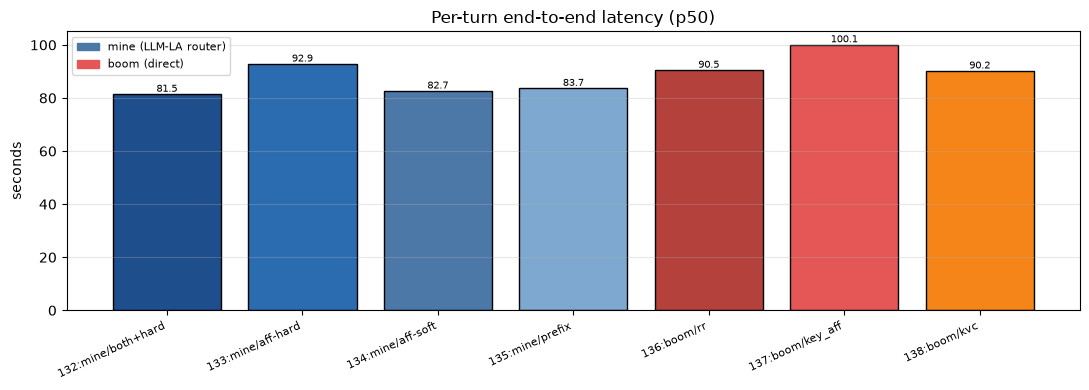

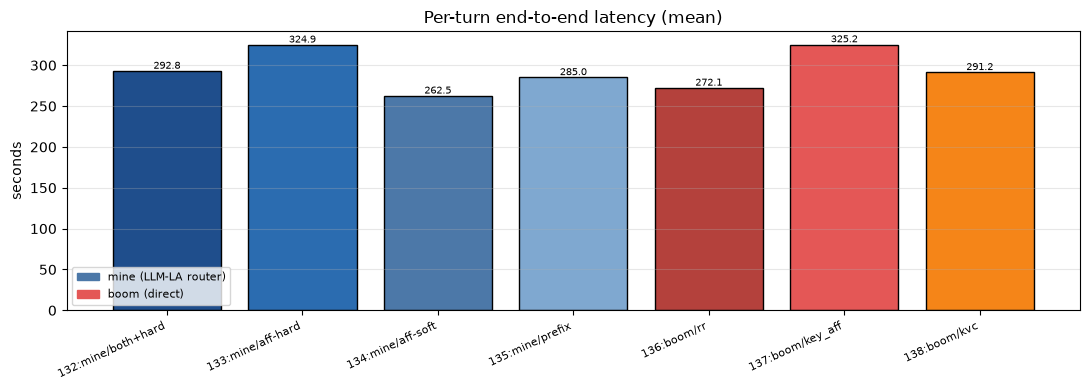

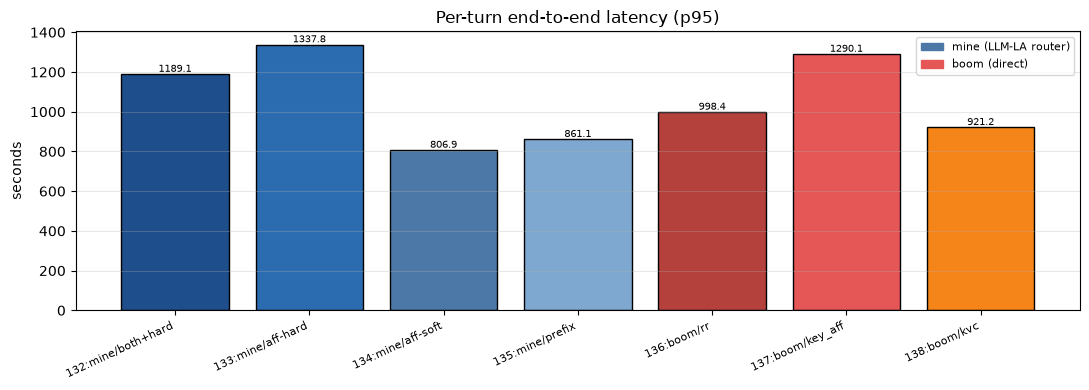

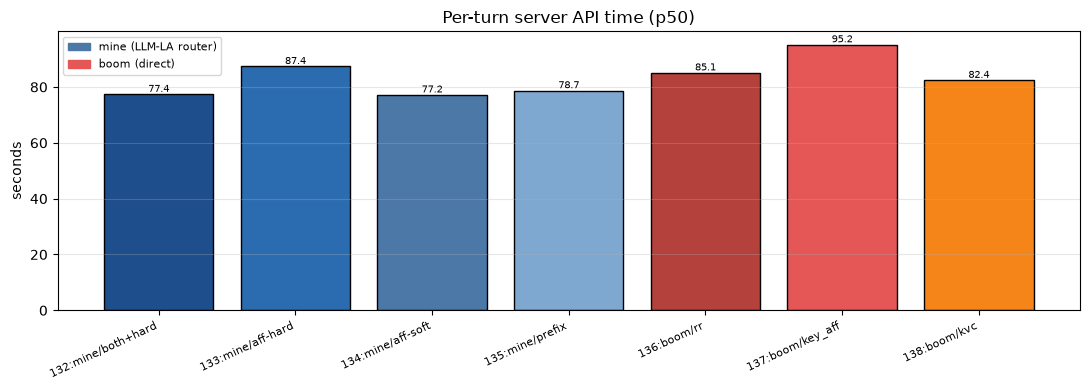

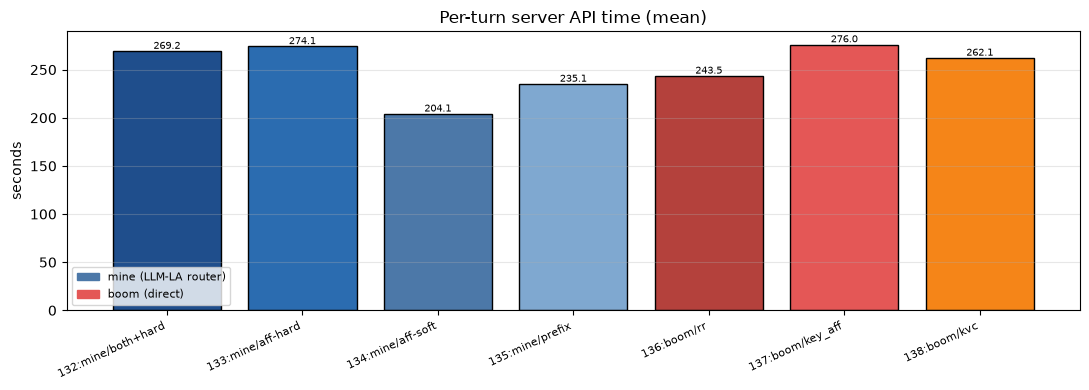

In [4]:
e2e_p50 = TURNS.groupby("exp")["end_to_end_s"].quantile(.50).to_dict()
e2e_p95 = TURNS.groupby("exp")["end_to_end_s"].quantile(.95).to_dict()
e2e_mean = TURNS.groupby("exp")["end_to_end_s"].mean().to_dict()
bar_by_exp(e2e_p50, "Per-turn end-to-end latency (p50)", "seconds", fmt="{:.1f}")
bar_by_exp(e2e_mean, "Per-turn end-to-end latency (mean)", "seconds", fmt="{:.1f}")
bar_by_exp(e2e_p95, "Per-turn end-to-end latency (p95)", "seconds", fmt="{:.1f}")

# server API time: p50 + mean
api_p50 = TURNS.groupby("exp")["api_s"].quantile(.50).to_dict()
api_mean = TURNS.groupby("exp")["api_s"].mean().to_dict()
bar_by_exp(api_p50, "Per-turn server API time (p50)", "seconds", fmt="{:.1f}")
bar_by_exp(api_mean, "Per-turn server API time (mean)", "seconds", fmt="{:.1f}")

### 2b. Latency by turn index
Does latency improve on later turns of a conversation (context reuse paying off)?

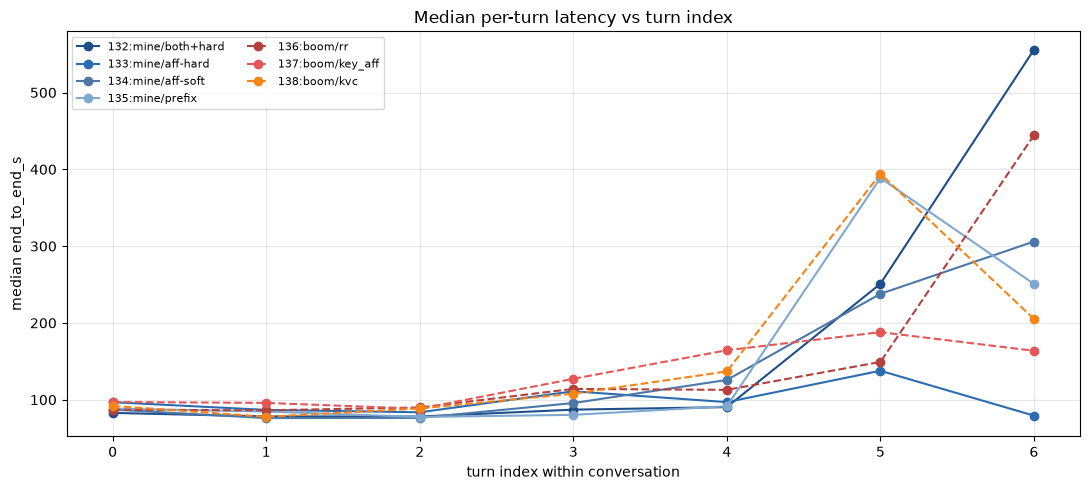

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for e in EXP_IDS:
    d = TURNS[TURNS["exp"] == e]
    m = d.groupby("turn_idx")["end_to_end_s"].median()
    if m.empty:
        continue
    ax.plot(m.index, m.values, marker="o", color=COLORS[e], label=LABELS[e],
            ls="--" if side(e) == "boom" else "-")
ax.set_xlabel("turn index within conversation"); ax.set_ylabel("median end_to_end_s")
ax.set_title("Median per-turn latency vs turn index"); ax.grid(alpha=.3)
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

### 2c. Latency distributions (violin)
Full per-turn distribution shape for each latency metric. Y-axis is clipped to the
98th percentile for readability (extreme tails exist above the shown range).

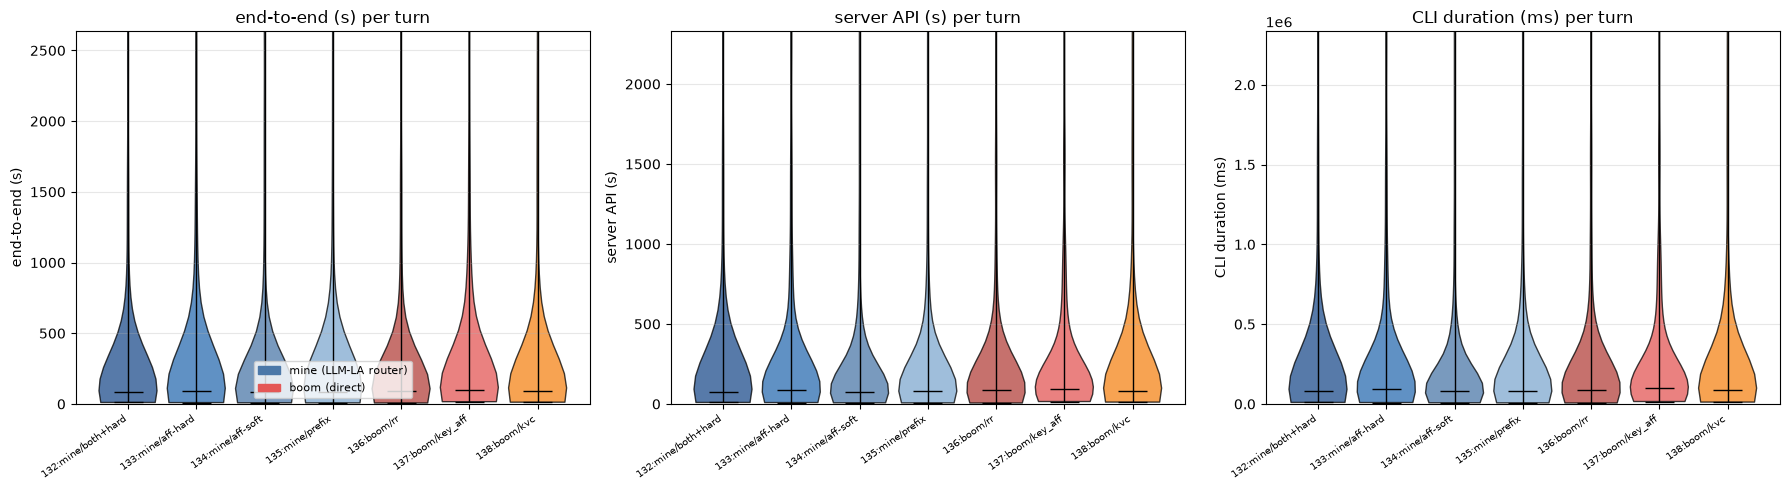

In [6]:
lat_metrics = [("end_to_end_s", "end-to-end (s)"),
               ("api_s", "server API (s)"),
               ("duration_ms", "CLI duration (ms)")]
lat_metrics = [(c, t) for c, t in lat_metrics
               if c in TURNS.columns and TURNS[c].notna().any()]
fig, axes = plt.subplots(1, len(lat_metrics), figsize=(6 * len(lat_metrics), 5))
if len(lat_metrics) == 1:
    axes = [axes]
for ax, (col, ttl) in zip(axes, lat_metrics):
    data = [TURNS[TURNS["exp"] == e][col].dropna().values for e in EXP_IDS]
    parts = ax.violinplot(data, showmedians=True, showextrema=True, widths=0.85)
    for pc, e in zip(parts["bodies"], EXP_IDS):
        pc.set_facecolor(COLORS[e]); pc.set_edgecolor("black"); pc.set_alpha(0.75)
    for key in ("cmedians", "cmaxes", "cmins", "cbars"):
        if key in parts:
            parts[key].set_color("black"); parts[key].set_linewidth(1.0)
    ax.set_xticks(range(1, len(EXP_IDS) + 1))
    ax.set_xticklabels([LABELS[e] for e in EXP_IDS], rotation=35, ha="right", fontsize=7)
    cap = TURNS[col].quantile(.98)
    if pd.notna(cap) and cap > 0:
        ax.set_ylim(0, cap * 1.05)
    ax.set_title(f"{ttl} per turn"); ax.set_ylabel(ttl); ax.grid(axis="y", alpha=.3)
axes[0].legend(handles=[Patch(color="#4C78A8", label="mine (LLM-LA router)"),
                        Patch(color="#E45756", label="boom (direct)")], fontsize=8)
plt.tight_layout(); plt.show()

### 2d. Router-side engine timing: TTFT / TPOT / model latency (mine only)
Real per-token metrics are captured per router sub-request via streaming, so they
exist **only for the mine cells** (LLM-LA router). BooM runs direct with no router
log. The engine ground-truth for **both** paths is backfilled from Prometheus in S2e.
The last table gives an output-rate proxy (`completion_tokens / api_s`) computable for
both paths, but it folds in prefill + tool-loop overhead and is not a true TPOT.

=== TTFT (s) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
132:mine/both+hard,2691.0,1.204,2.036,2.330,1.352
133:mine/aff-hard,2856.0,1.148,2.071,2.463,1.330
134:mine/aff-soft,2570.0,1.239,2.250,2.629,1.429
135:mine/prefix,2733.0,1.281,2.377,2.743,1.483


=== TPOT (s/token) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
132:mine/both+hard,2690.0,0.055,0.067,0.072,0.056
133:mine/aff-hard,2856.0,0.056,0.068,0.073,0.056
134:mine/aff-soft,2570.0,0.055,0.065,0.069,0.055
135:mine/prefix,2733.0,0.056,0.067,0.072,0.056


=== model latency (s) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
132:mine/both+hard,2691.0,18.638,91.879,152.857,44.836
133:mine/aff-hard,2856.0,19.016,94.469,153.997,46.010
134:mine/aff-soft,2570.0,17.899,87.602,142.727,38.777
135:mine/prefix,2733.0,18.609,92.808,138.953,41.315


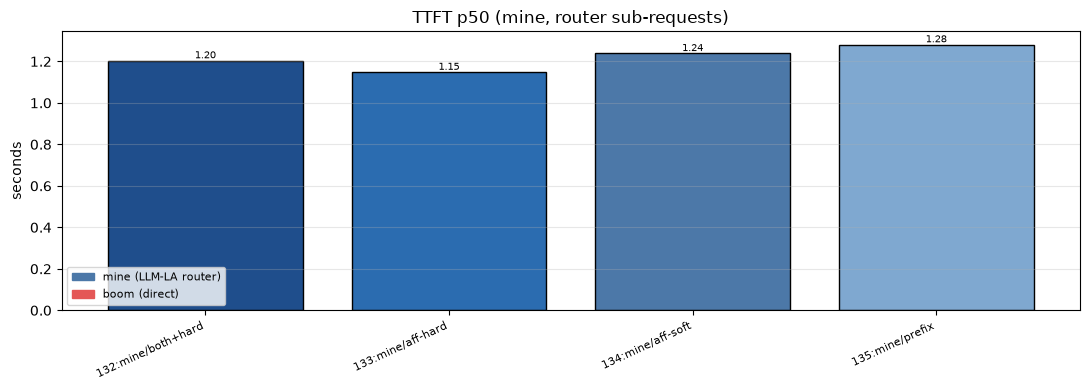

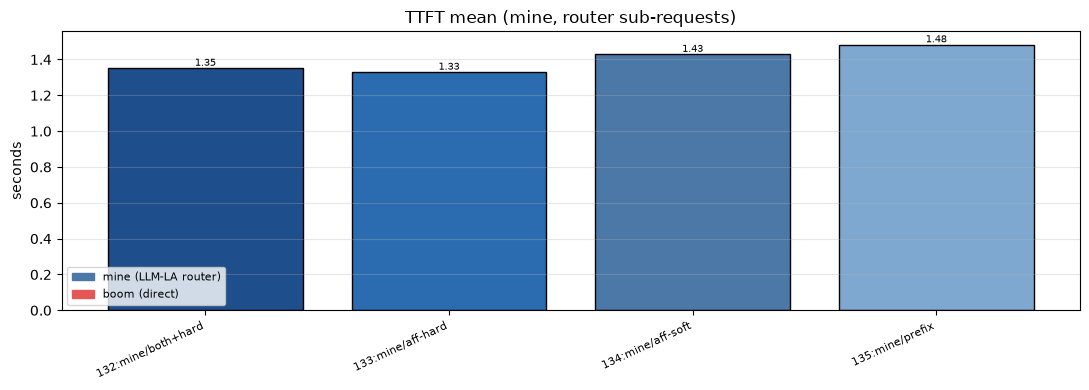

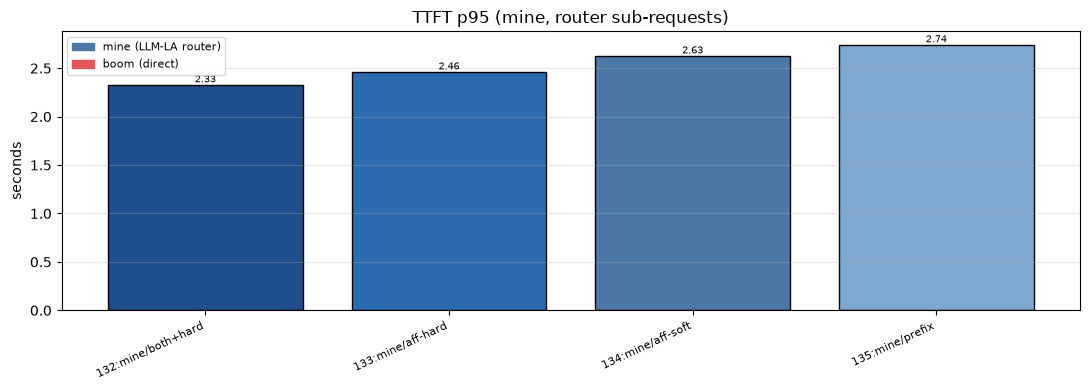

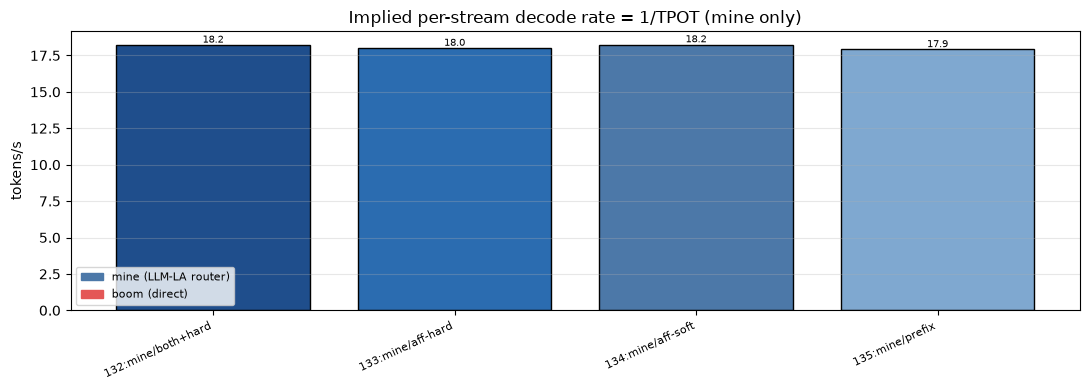

=== output-rate proxy: completion_tokens / api_s (per turn, BOTH paths) ===


,n,mean,p50,p90,p95,p99,max
132:mine/both+hard,453,17.42,17.36,19.27,19.82,28.40,29.61
133:mine/aff-hard,448,17.70,17.55,20.06,21.27,28.45,29.65
134:mine/aff-soft,438,17.24,17.23,19.27,20.16,22.33,29.79
135:mine/prefix,447,17.19,17.01,19.38,20.42,22.25,23.18
136:boom/rr,451,17.58,17.40,19.32,19.71,22.92,27.21
137:boom/key_aff,448,14.62,14.41,15.94,16.28,18.36,29.02
138:boom/kvc,451,17.27,17.24,20.28,21.44,29.08,29.76


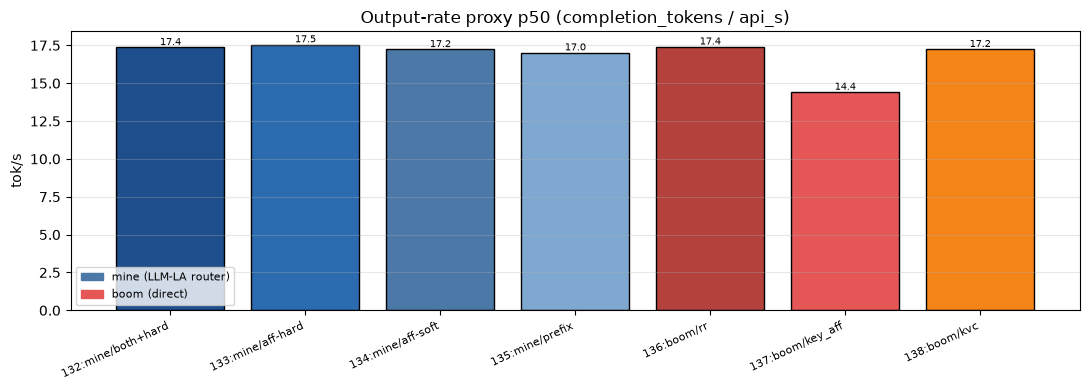

In [7]:
def _pctl(g):
    return pd.Series({"n": len(g), "p50": g.quantile(.50),
                      "p90": g.quantile(.90), "p95": g.quantile(.95),
                      "mean": g.mean()})

eng_rows = {}
for e in EXP_IDS:
    if side(e) != "mine":
        continue
    rl = pd.DataFrame(_read_ndjson(exp_dir(e) / "logs.json"))
    if rl.empty:
        continue
    if "send_failed" in rl.columns:
        rl = rl[rl["send_failed"] != True]
    for c in ["ttft_s", "tpot_avg_s", "model_latency_s"]:
        rl[c] = pd.to_numeric(rl.get(c), errors="coerce")
    eng_rows[e] = rl

for col, ttl in [("ttft_s", "TTFT (s)"), ("tpot_avg_s", "TPOT (s/token)"),
                 ("model_latency_s", "model latency (s)")]:
    tbl = pd.DataFrame({LABELS[e]: _pctl(rl[col].dropna())
                        for e, rl in eng_rows.items()}).T
    print(f"=== {ttl} — per router sub-request (mine only) ===")
    display(tbl.round(3))

ttft_p50 = {e: eng_rows[e]["ttft_s"].median() for e in eng_rows}
ttft_p95 = {e: eng_rows[e]["ttft_s"].quantile(.95) for e in eng_rows}
ttft_mean = {e: eng_rows[e]["ttft_s"].mean() for e in eng_rows}
bar_by_exp(ttft_p50, "TTFT p50 (mine, router sub-requests)", "seconds", fmt="{:.2f}")
bar_by_exp(ttft_mean, "TTFT mean (mine, router sub-requests)", "seconds", fmt="{:.2f}")
bar_by_exp(ttft_p95, "TTFT p95 (mine, router sub-requests)", "seconds", fmt="{:.2f}")

tpot_rate = {e: (1.0 / eng_rows[e]["tpot_avg_s"].median())
             for e in eng_rows if eng_rows[e]["tpot_avg_s"].median()}
bar_by_exp(tpot_rate, "Implied per-stream decode rate = 1/TPOT (mine only)",
           "tokens/s", fmt="{:.1f}")

TURNS["out_tok_per_s"] = TURNS["completion_tokens"] / TURNS["api_s"].replace(0, np.nan)
proxy = pctl_table(TURNS[TURNS["out_tok_per_s"].replace([np.inf, -np.inf], np.nan).notna()],
                   "out_tok_per_s")
print("=== output-rate proxy: completion_tokens / api_s (per turn, BOTH paths) ===")
display(proxy.round(2))
bar_by_exp({e: TURNS[TURNS["exp"] == e]["out_tok_per_s"]
            .replace([np.inf, -np.inf], np.nan).median() for e in EXP_IDS},
           "Output-rate proxy p50 (completion_tokens / api_s)", "tok/s", fmt="{:.1f}")

### 2e. Engine-side TTFT / e2e / throughput / prefix-cache (backfilled from Prometheus)
The live client scraper only stored per-pod gauges, but the central Prometheus
(`http://192.168.0.79:31190`) **retains the vLLM histogram counters**, so we backfill
true engine metrics for **all 7 cells (boom included)** over each cell's exact
`metrics.jsonl` window using `increase(...)` / `histogram_quantile(...)`.
Cached to `prom_engine_backfill_u32.json`; delete that file to regenerate against
live Prometheus.

Because the boom cells here are the **post `strip_claude_code_attribution` fix** re-runs,
their engine prefix-cache hit rate should now be **non-zero** (the fix removes the rotating
`cch=` block that previously forced a 100% miss). The table below is the decisive
apples-to-apples check on whether mine still leads on prefix reuse and TTFT after that fix.
`time_per_output_token_seconds` is not exported by this vLLM build, so TPOT is derived
as `(e2e_avg - ttft_avg) / gen_tokens_per_req`.

cache missing -> querying Prometheus live ...


,reqs,ttft_p50,ttft_p95,ttft_avg,e2e_p50,e2e_p95,e2e_avg,tpot_derived_s,decode_tok_s,prefix_hit_rate
132:mine/both+hard,2699.306,0.764,2.063,0.842,18.333,183.456,44.935,0.057,132.401,0.916
133:mine/aff-hard,2872.993,0.767,2.092,0.850,18.770,181.428,47.690,0.058,199.619,0.909
134:mine/aff-soft,2576.354,0.841,2.212,0.909,17.642,156.916,38.705,0.055,123.315,0.808
135:mine/prefix,2735.208,0.862,2.288,0.949,17.925,167.039,40.775,0.057,136.666,0.817
136:boom/rr,2816.783,0.801,2.055,0.857,17.253,143.853,39.132,0.057,126.567,0.816
137:boom/key_aff,2755.827,0.734,2.123,0.849,21.815,197.735,49.932,0.067,120.375,0.909
138:boom/kvc,2841.724,0.775,2.196,0.881,18.364,175.703,41.748,0.060,172.897,0.865


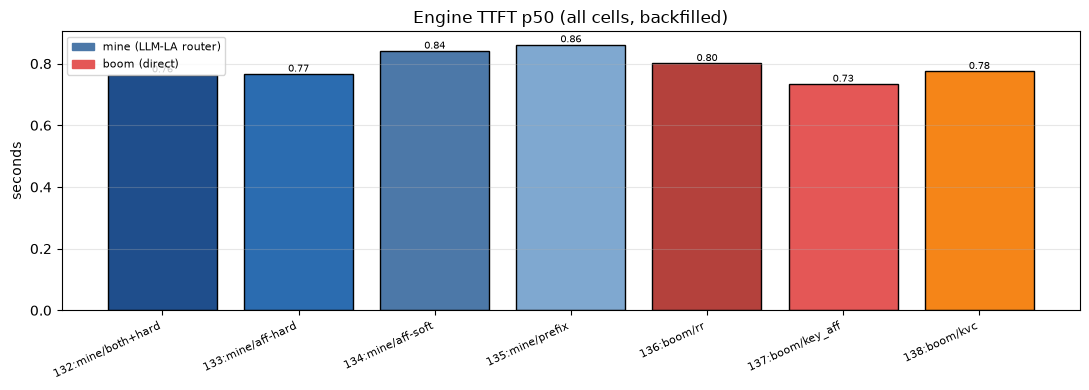

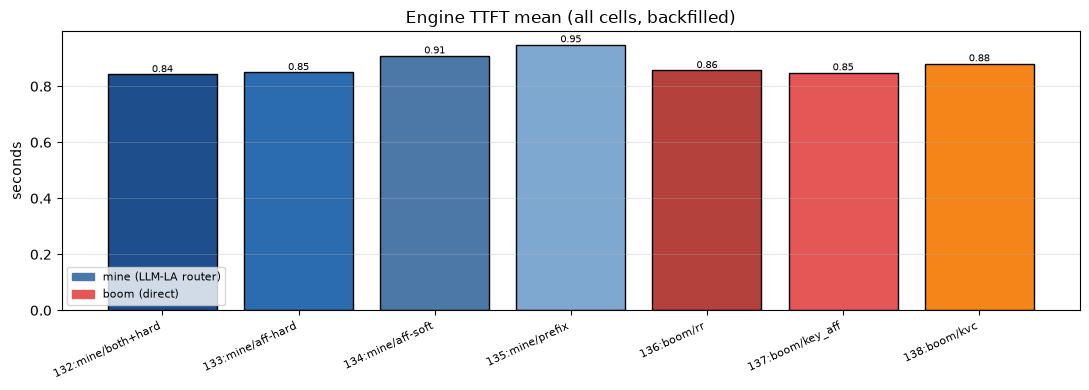

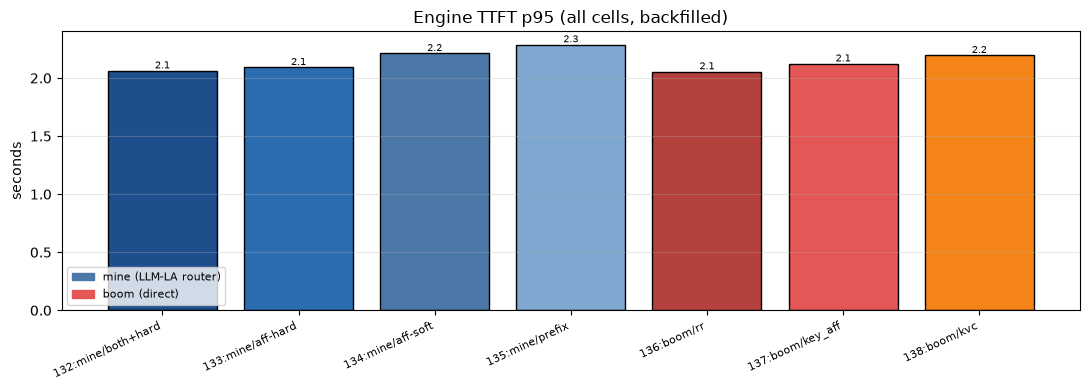

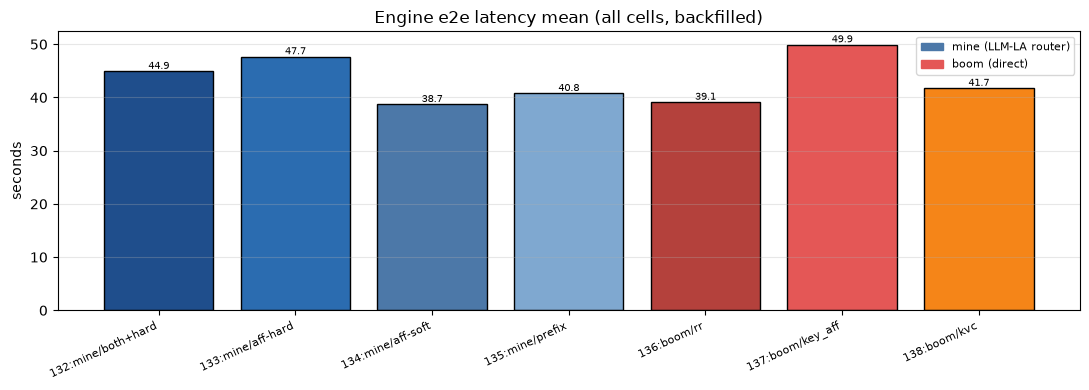

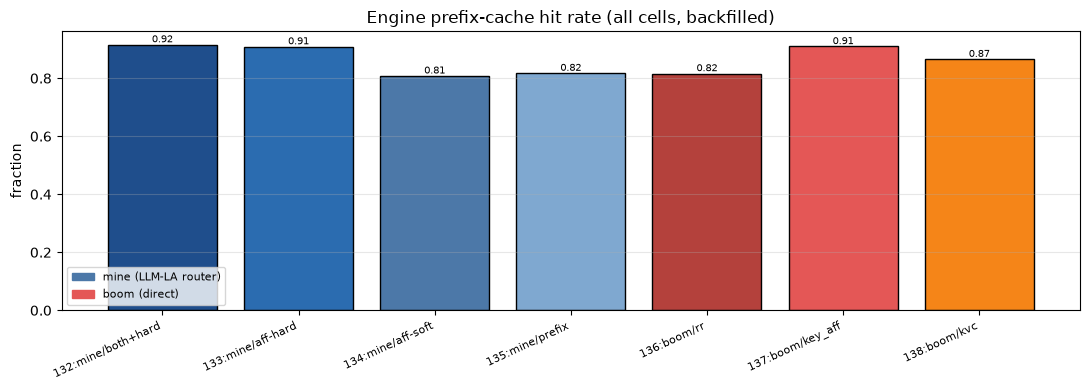

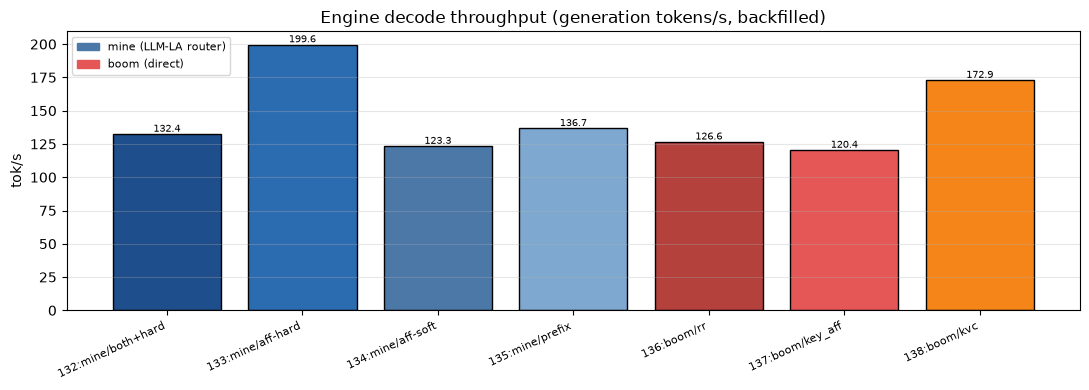

In [8]:
BACKFILL_PATH = Path(EXPERIMENTS_ROOT) / "prom_engine_backfill_u32.json"
PROM_BASE = "http://192.168.0.79:31190"

def _iso2unix(s):
    from datetime import datetime
    return datetime.fromisoformat(s).timestamp()

def _win(e):
    ts = [r.get("ts") for r in _read_ndjson(exp_dir(e) / "metrics.jsonl") if r.get("ts")]
    return _iso2unix(ts[0]), _iso2unix(ts[-1])

def backfill_live():
    """Query Prometheus directly (fallback when the cache file is absent)."""
    import requests
    def q(expr, t):
        r = requests.get(f"{PROM_BASE}/api/v1/query",
                         params={"query": expr, "time": t}, timeout=25)
        res = r.json().get("data", {}).get("result", [])
        if not res:
            return None
        v = res[0]["value"][1]
        return None if v in ("NaN", None) else float(v)
    V = "vllm:"; out = {}
    for e in EXP_IDS:
        s, en = _win(e); d = int(en - s)
        a = lambda expr: q(expr, en)
        tsum = a(f"sum(increase({V}time_to_first_token_seconds_sum[{d}s]))")
        tcnt = a(f"sum(increase({V}time_to_first_token_seconds_count[{d}s]))")
        esum = a(f"sum(increase({V}e2e_request_latency_seconds_sum[{d}s]))")
        ecnt = a(f"sum(increase({V}e2e_request_latency_seconds_count[{d}s]))")
        gen = a(f"sum(increase({V}generation_tokens_total[{d}s]))")
        hits = a(f"sum(increase({V}prefix_cache_hits_total[{d}s]))")
        qrs = a(f"sum(increase({V}prefix_cache_queries_total[{d}s]))")
        rec = {"label": LABELS[e], "dur_s": d, "reqs": ecnt,
               "ttft_avg": (tsum / tcnt) if tsum and tcnt else None,
               "ttft_p50": a(f"histogram_quantile(0.50, sum by (le)(increase({V}time_to_first_token_seconds_bucket[{d}s])))"),
               "ttft_p95": a(f"histogram_quantile(0.95, sum by (le)(increase({V}time_to_first_token_seconds_bucket[{d}s])))"),
               "e2e_avg": (esum / ecnt) if esum and ecnt else None,
               "e2e_p50": a(f"histogram_quantile(0.50, sum by (le)(increase({V}e2e_request_latency_seconds_bucket[{d}s])))"),
               "e2e_p95": a(f"histogram_quantile(0.95, sum by (le)(increase({V}e2e_request_latency_seconds_bucket[{d}s])))"),
               "gen_tokens": gen, "decode_tok_s": (gen / d) if gen else None,
               "prefix_hit_rate": (hits / qrs) if (qrs and qrs > 0) else None}
        if rec["e2e_avg"] and rec["ttft_avg"] and gen and ecnt:
            rec["tpot_derived_s"] = (rec["e2e_avg"] - rec["ttft_avg"]) / (gen / ecnt)
        out[str(e)] = rec
    return out

if BACKFILL_PATH.is_file():
    BF = json.load(BACKFILL_PATH.open())
    print("loaded cached backfill:", BACKFILL_PATH.name)
else:
    print("cache missing -> querying Prometheus live ...")
    BF = backfill_live()
    json.dump(BF, BACKFILL_PATH.open("w"), indent=2)

ENG = pd.DataFrame({LABELS[e]: BF.get(str(e), {}) for e in EXP_IDS}).T
cols = ["reqs", "ttft_p50", "ttft_p95", "ttft_avg", "e2e_p50", "e2e_p95",
        "e2e_avg", "tpot_derived_s", "decode_tok_s", "prefix_hit_rate"]
cols = [c for c in cols if c in ENG.columns]
display(ENG[cols].astype(float).round(3))

bar_by_exp({e: float(BF[str(e)]["ttft_p50"]) for e in EXP_IDS if BF.get(str(e), {}).get("ttft_p50") is not None},
           "Engine TTFT p50 (all cells, backfilled)", "seconds", fmt="{:.2f}")
bar_by_exp({e: float(BF[str(e)]["ttft_avg"]) for e in EXP_IDS if BF.get(str(e), {}).get("ttft_avg") is not None},
           "Engine TTFT mean (all cells, backfilled)", "seconds", fmt="{:.2f}")
bar_by_exp({e: float(BF[str(e)]["ttft_p95"]) for e in EXP_IDS if BF.get(str(e), {}).get("ttft_p95") is not None},
           "Engine TTFT p95 (all cells, backfilled)", "seconds", fmt="{:.1f}")
bar_by_exp({e: float(BF[str(e)]["e2e_avg"]) for e in EXP_IDS if BF.get(str(e), {}).get("e2e_avg") is not None},
           "Engine e2e latency mean (all cells, backfilled)", "seconds", fmt="{:.1f}")
bar_by_exp({e: float(BF[str(e)]["prefix_hit_rate"]) for e in EXP_IDS if BF.get(str(e), {}).get("prefix_hit_rate") is not None},
           "Engine prefix-cache hit rate (all cells, backfilled)", "fraction", fmt="{:.2f}")
bar_by_exp({e: float(BF[str(e)]["decode_tok_s"]) for e in EXP_IDS if BF.get(str(e), {}).get("decode_tok_s") is not None},
           "Engine decode throughput (generation tokens/s, backfilled)", "tok/s", fmt="{:.1f}")

## 3. Makespan & throughput
Same 128-conversation workload under the same closed-loop concurrency, so total makespan
(`load_runner_duration_s`) measures how fast each strategy cleared the work.
Throughput is derived from the per-turn logs (path-agnostic), normalized by makespan.

,makespan_min,turns,turns_per_min,decode_tok_s,prompt_tok_s
label,,,,,
132:mine/both+hard,263.4,453,1.72,128.5,6659.9
133:mine/aff-hard,193.8,450,2.32,169.6,9212.4
134:mine/aff-soft,238.5,446,1.87,102.2,5847.5
135:mine/prefix,234.6,449,1.91,126.8,7217.1
136:boom/rr,250.5,452,1.80,126.0,7094.2
137:boom/key_aff,280.9,450,1.60,108.2,5898.8
138:boom/kvc,187.7,452,2.41,171.9,9765.5


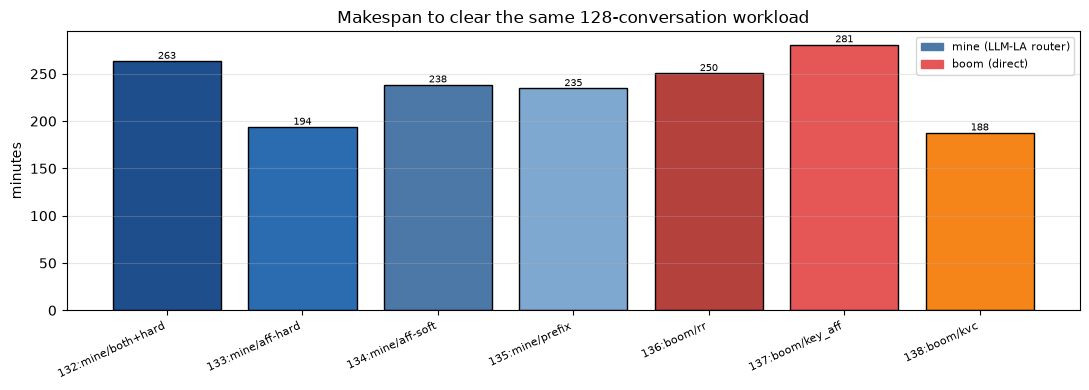

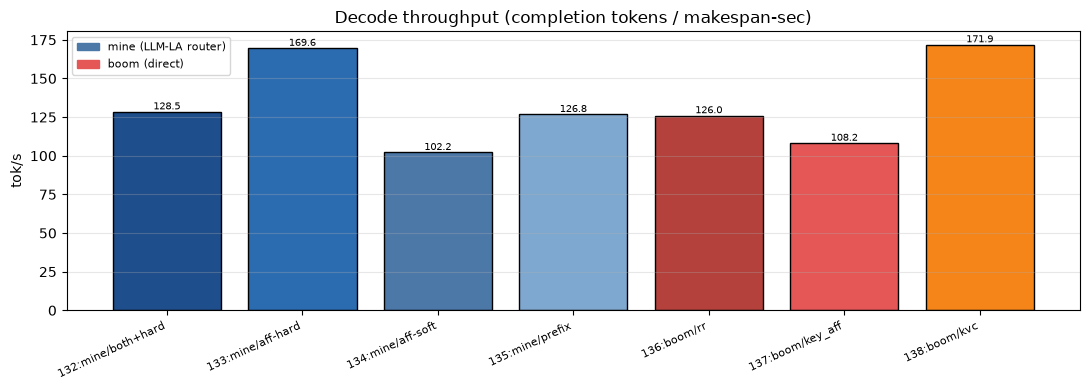

In [9]:
rows = []
for e in EXP_IDS:
    d = TURNS[TURNS["exp"] == e]
    load_s = REG.loc[e, "load_s"] or np.nan
    comp = d["completion_tokens"].sum()
    prompt = d["prompt_tokens"].sum()
    rows.append({
        "label": LABELS[e], "exp": e,
        "makespan_min": round(load_s / 60, 1) if pd.notna(load_s) else np.nan,
        "turns": len(d),
        "turns_per_min": round(len(d) / (load_s / 60), 2) if pd.notna(load_s) else np.nan,
        "decode_tok_s": round(comp / load_s, 1) if pd.notna(load_s) else np.nan,
        "prompt_tok_s": round(prompt / load_s, 1) if pd.notna(load_s) else np.nan,
        "sum_completion_tok": int(comp), "sum_prompt_tok": int(prompt),
    })
THRU = pd.DataFrame(rows).set_index("label")
display(THRU[["makespan_min", "turns", "turns_per_min", "decode_tok_s",
              "prompt_tok_s"]])

bar_by_exp({e: REG.loc[e, "load_s"] / 60 for e in EXP_IDS},
           "Makespan to clear the same 128-conversation workload", "minutes", fmt="{:.0f}")
bar_by_exp({r["exp"]: r["decode_tok_s"] for r in rows},
           "Decode throughput (completion tokens / makespan-sec)", "tok/s", fmt="{:.1f}")

## 4. Token profile
Sanity check on request size: prompt and completion tokens per turn.

,prompt_p50,prompt_p95,prompt_max,comp_p50,comp_p95,comp_max
132:mine/both+hard,105488.0,835929.0,6204441.0,1339.0,17149.0,121988.0
133:mine/aff-hard,108696.0,775706.0,7907018.0,1553.0,19484.0,79692.0
134:mine/aff-soft,101506.0,515658.0,5408440.0,1296.0,10699.0,98578.0
135:mine/prefix,110187.0,714932.0,5824082.0,1360.0,13925.0,112640.0
136:boom/rr,116406.0,791919.0,6293070.0,1497.0,15758.0,100756.0
137:boom/key_aff,107396.0,680914.0,3877953.0,1437.0,15977.0,72144.0
138:boom/kvc,111430.0,811410.0,6302202.0,1455.0,14558.0,125364.0


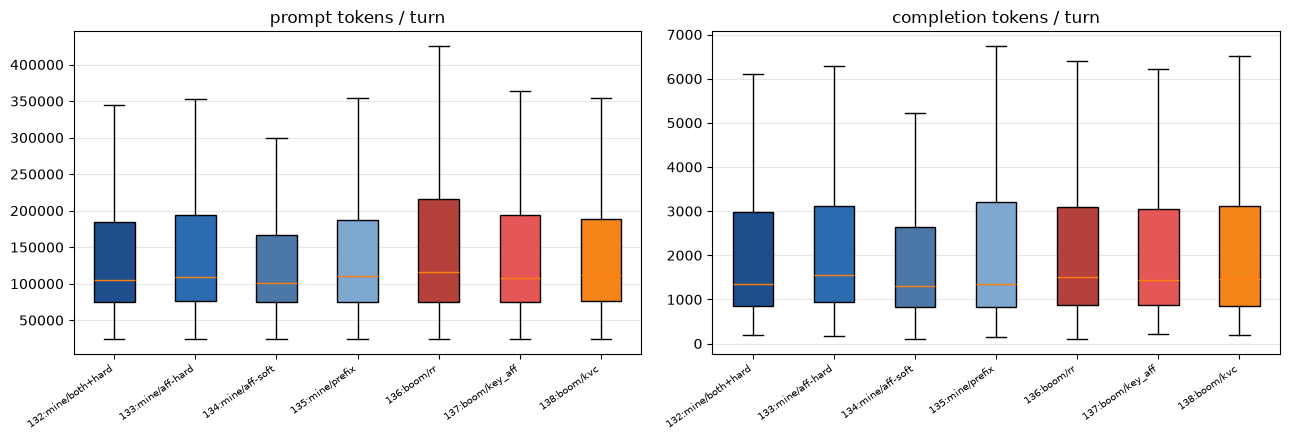

In [10]:
tok = TURNS.groupby("exp").agg(
    prompt_p50=("prompt_tokens", lambda s: s.quantile(.50)),
    prompt_p95=("prompt_tokens", lambda s: s.quantile(.95)),
    prompt_max=("prompt_tokens", "max"),
    comp_p50=("completion_tokens", lambda s: s.quantile(.50)),
    comp_p95=("completion_tokens", lambda s: s.quantile(.95)),
    comp_max=("completion_tokens", "max"),
)
tok.index = [LABELS[e] for e in tok.index]
display(tok.round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, ttl in [(axes[0], "prompt_tokens", "prompt tokens / turn"),
                     (axes[1], "completion_tokens", "completion tokens / turn")]:
    data = [TURNS[TURNS["exp"] == e][col].dropna().values for e in EXP_IDS]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True)
    for patch, e in zip(bp["boxes"], EXP_IDS):
        patch.set_facecolor(COLORS[e])
    ax.set_xticks(range(1, len(EXP_IDS) + 1))
    ax.set_xticklabels([LABELS[e] for e in EXP_IDS], rotation=35, ha="right", fontsize=7)
    ax.set_title(ttl)
    ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 5. Router-level KV reuse (mine only)
BooM runs in **direct** mode with no router log, so `kv_hit` / `matched_tokens`
exist only for the LLM-LA cells. This is the per-router-request prefix-cache hit
seen by our router. The engine ground-truth for both paths is in S2e.

,router_reqs,kv_hit_frac,matched_tok_p50,matched_frac_of_prompt
label,,,,
132:mine/both+hard,2691,0.5050,2304.0,0.0278
133:mine/aff-hard,2856,0.8232,128.0,0.0049
134:mine/aff-soft,2570,0.5109,2304.0,0.0272
135:mine/prefix,2733,0.9835,2304.0,0.0187


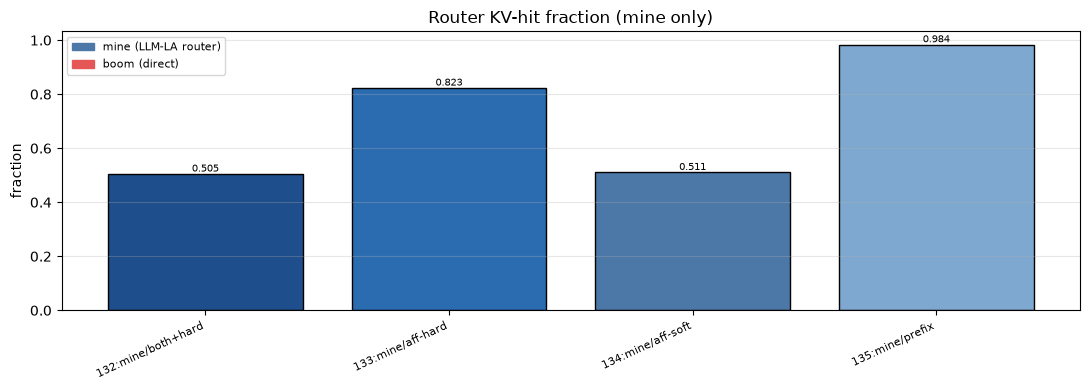

In [11]:
kv_rows = []
for e in EXP_IDS:
    if side(e) != "mine":
        continue
    rl = pd.DataFrame(_read_ndjson(exp_dir(e) / "logs.json"))
    if rl.empty or "kv_hit" not in rl.columns:
        continue
    rl = rl[rl.get("send_failed", False) != True] if "send_failed" in rl.columns else rl
    kh = rl["kv_hit"].dropna().astype(bool)
    mt = pd.to_numeric(rl.get("matched_tokens"), errors="coerce")
    pt = pd.to_numeric(rl.get("prompt_tokens"), errors="coerce")
    kv_rows.append({
        "label": LABELS[e], "router_reqs": len(rl),
        "kv_hit_frac": round(kh.mean(), 4) if len(kh) else np.nan,
        "matched_tok_p50": round(mt.median(), 0) if mt.notna().any() else np.nan,
        "matched_frac_of_prompt": round((mt / pt).replace([np.inf, -np.inf], np.nan).median(), 4)
            if mt.notna().any() and pt.notna().any() else np.nan,
    })
KVR = pd.DataFrame(kv_rows).set_index("label")
display(KVR)
if not KVR.empty:
    vals = {int(l.split(":")[0]): KVR.loc[l, "kv_hit_frac"] for l in KVR.index}
    bar_by_exp(vals, "Router KV-hit fraction (mine only)", "fraction", fmt="{:.3f}")

## 6. vLLM fleet metrics (`metrics.jsonl`)
Recomputed per-pod (engine `prefix_cache_hit_rate` came back empty, so we use
`kv_cache_usage_perc` and `requests_running` — the reliable engine signals).

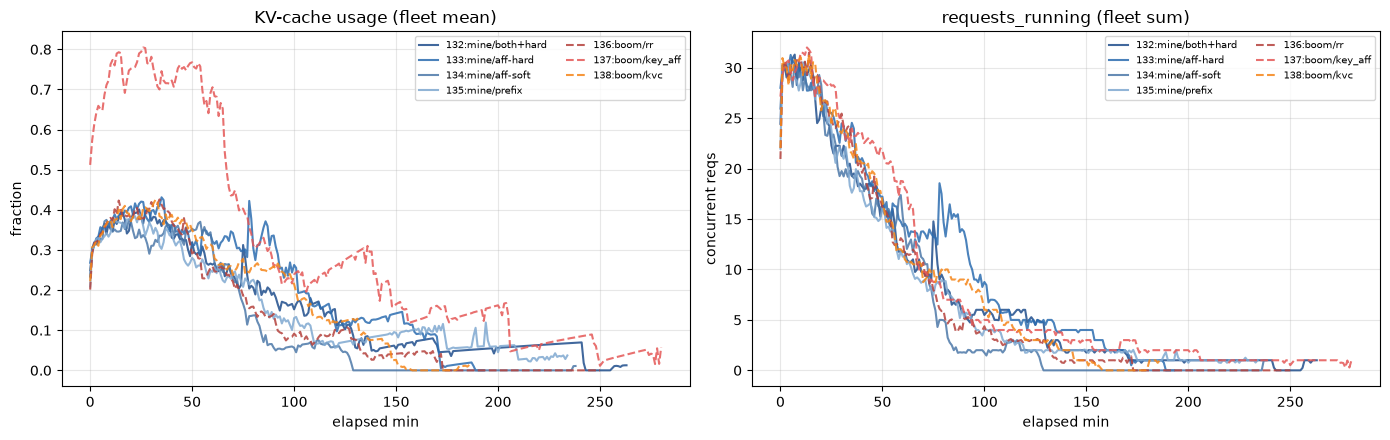

In [12]:
def load_ts(e):
    out = []
    for r in _read_ndjson(exp_dir(e) / "metrics.jsonl"):
        ts = r.get("ts")
        for s in (r.get("samples") or []):
            if s.get("kv_cache_usage_perc") is None and s.get("requests_running") is None:
                continue
            out.append({"ts": ts, "pod": s.get("pod") or s.get("instance"),
                        "kv_cache_usage_perc": s.get("kv_cache_usage_perc"),
                        "requests_running": s.get("requests_running"),
                        "requests_waiting": s.get("requests_waiting")})
    df = pd.DataFrame(out)
    if df.empty:
        return df
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df = df.dropna(subset=["ts"])
    df["t_min"] = (df["ts"] - df["ts"].min()).dt.total_seconds() / 60
    return df

TS = {e: load_ts(e) for e in EXP_IDS}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for e in EXP_IDS:
    d = TS[e]
    if d.empty:
        continue
    for ax, col, agg in [(axes[0], "kv_cache_usage_perc", "mean"),
                         (axes[1], "requests_running", "sum")]:
        g = d.groupby("ts")[col]
        fleet = g.mean() if agg == "mean" else g.sum()
        tt = d.groupby("ts")["t_min"].first()
        s = pd.DataFrame({"t": tt, "v": fleet}).dropna()
        s["bin"] = (s["t"] // 1).astype(int)
        b = s.groupby("bin")["v"].mean()
        ax.plot(b.index, b.values, color=COLORS[e], label=LABELS[e],
                ls="--" if side(e) == "boom" else "-", alpha=.85)
axes[0].set_title("KV-cache usage (fleet mean)"); axes[0].set_ylabel("fraction")
axes[1].set_title("requests_running (fleet sum)"); axes[1].set_ylabel("concurrent reqs")
for ax in axes:
    ax.set_xlabel("elapsed min"); ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 7. Load balance across pods
How evenly each strategy spread work over the vLLM leader pods.
For *mine* we use `endpoint_tokens.json` (real endpoints); for all cells we also
use time-averaged `requests_running` per pod from `metrics.jsonl`.
Jain fairness index: 1.0 = perfectly balanced, lower = concentrated on fewer pods.
Watch `boom/key_aff` here — at low concurrency BooM's load-driven affinity can collapse
onto a single pod (all loads tie at ~0, tie-break picks candidates[0]).

,pods_active,jain_running,jain_tokens,pod_running_share
label,,,,
132:mine/both+hard,2,0.923,0.867,"{'vllm-minimax-m2-0': 2.68, 'vllm-minimax-m2-1..."
133:mine/aff-hard,2,0.957,0.985,"{'vllm-minimax-m2-0': 4.57, 'vllm-minimax-m2-1..."
134:mine/aff-soft,2,0.999,0.998,"{'vllm-minimax-m2-0': 3.44, 'vllm-minimax-m2-1..."
135:mine/prefix,2,0.995,0.998,"{'vllm-minimax-m2-0': 3.59, 'vllm-minimax-m2-1..."
136:boom/rr,2,0.999,NaN,"{'vllm-minimax-m2-0': 4.14, 'vllm-minimax-m2-1..."
137:boom/key_aff,1,1.000,NaN,{'vllm-minimax-m2-0': 8.08}
138:boom/kvc,2,0.841,NaN,"{'vllm-minimax-m2-0': 7.41, 'vllm-minimax-m2-1..."


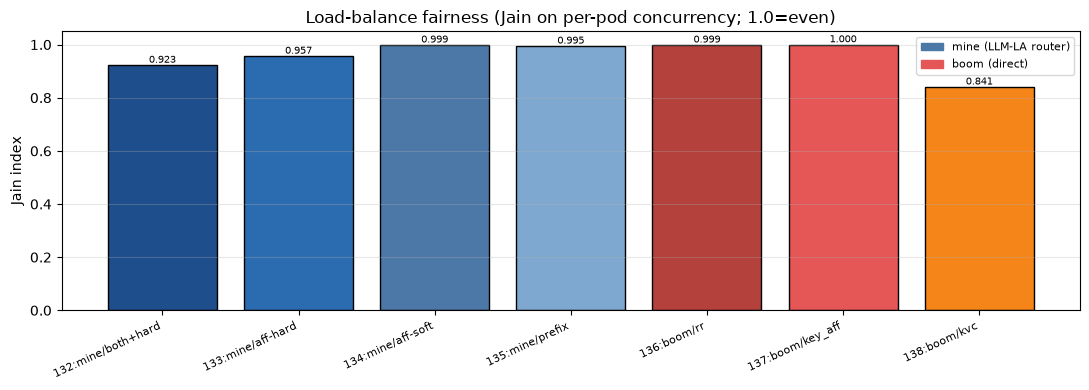

In [13]:
def jain(x):
    x = np.asarray([v for v in x if v is not None and not np.isnan(v)], dtype=float)
    if x.size == 0 or x.sum() == 0:
        return np.nan
    return (x.sum() ** 2) / (x.size * (x ** 2).sum())

lb_rows = []
for e in EXP_IDS:
    d = TS[e]
    per_pod = d.groupby("pod")["requests_running"].mean() if not d.empty else pd.Series(dtype=float)
    pods_seen = int((per_pod > 0).sum()) if not per_pod.empty else 0
    et = _read_json(exp_dir(e) / "endpoint_tokens.json") or {}
    pe = {p["endpoint"]: p["total_tokens"] for p in et.get("per_endpoint", [])}
    real_ep = {k: v for k, v in pe.items() if k != "_unknown_"}
    lb_rows.append({
        "label": LABELS[e],
        "pods_active": pods_seen,
        "jain_running": round(jain(per_pod.values), 3) if not per_pod.empty else np.nan,
        "jain_tokens": round(jain(list(real_ep.values())), 3) if real_ep else np.nan,
        "pod_running_share": {k: round(v, 2) for k, v in per_pod.round(2).to_dict().items()},
    })
LB = pd.DataFrame(lb_rows).set_index("label")
display(LB)

vals = {int(l.split(":")[0]): LB.loc[l, "jain_running"] for l in LB.index
        if pd.notna(LB.loc[l, "jain_running"])}
bar_by_exp(vals, "Load-balance fairness (Jain on per-pod concurrency; 1.0=even)",
           "Jain index", fmt="{:.3f}")

## 8. Head-to-head summary
Lower latency/makespan is better; higher throughput/kv_hit/fairness is better.

In [14]:
S = pd.DataFrame(index=[LABELS[e] for e in EXP_IDS])
S["side"] = [side(e) for e in EXP_IDS]
S["makespan_min"] = [round((REG.loc[e, "load_s"] or np.nan) / 60, 1) for e in EXP_IDS]
g50 = TURNS.groupby("exp")["end_to_end_s"].quantile(.50)
g95 = TURNS.groupby("exp")["end_to_end_s"].quantile(.95)
gmean = TURNS.groupby("exp")["end_to_end_s"].mean()
S["e2e_p50_s"] = [round(g50.get(e, np.nan), 1) for e in EXP_IDS]
S["e2e_p95_s"] = [round(g95.get(e, np.nan), 1) for e in EXP_IDS]
S["e2e_mean_s"] = [round(gmean.get(e, np.nan), 1) for e in EXP_IDS]
S["decode_tok_s"] = [THRU.loc[LABELS[e], "decode_tok_s"] for e in EXP_IDS]
S["kv_hit"] = [KVR.loc[LABELS[e], "kv_hit_frac"] if LABELS[e] in KVR.index else np.nan
               for e in EXP_IDS]
S["pods_active"] = [LB.loc[LABELS[e], "pods_active"] for e in EXP_IDS]
S["jain_running"] = [LB.loc[LABELS[e], "jain_running"] for e in EXP_IDS]

def _bf(e, k):
    v = BF.get(str(e), {}).get(k)
    return float(v) if v is not None else np.nan
S["eng_ttft_p50"] = [_bf(e, "ttft_p50") for e in EXP_IDS]
S["eng_ttft_p95"] = [_bf(e, "ttft_p95") for e in EXP_IDS]
S["eng_ttft_mean"] = [_bf(e, "ttft_avg") for e in EXP_IDS]
S["eng_e2e_mean"] = [_bf(e, "e2e_avg") for e in EXP_IDS]
S["eng_prefix_hit"] = [_bf(e, "prefix_hit_rate") for e in EXP_IDS]

print("Head-to-head")
display(S.round(3))

def _safe(idxfn, col):
    s = S[col].dropna()
    return (idxfn(s), s[idxfn(s)]) if not s.empty else (None, np.nan)
bl, blv = _safe(pd.Series.idxmin, "e2e_p50_s")
bm, bmv = _safe(pd.Series.idxmin, "makespan_min")
bt, btv = _safe(pd.Series.idxmax, "decode_tok_s")
bf, bfv = _safe(pd.Series.idxmin, "eng_ttft_p50")
bp, bpv = _safe(pd.Series.idxmax, "eng_prefix_hit")
print(f"\nBest p50 latency  : {bl}  ({blv} s)")
print(f"Best makespan     : {bm} ({bmv} min)")
print(f"Best throughput   : {bt} ({btv} tok/s)")
print(f"Best engine TTFT  : {bf} ({bfv} s p50)")
print(f"Best prefix-hit   : {bp} ({bpv})")

Head-to-head


,side,makespan_min,e2e_p50_s,e2e_p95_s,e2e_mean_s,decode_tok_s,kv_hit,pods_active,jain_running,eng_ttft_p50,eng_ttft_p95,eng_ttft_mean,eng_e2e_mean,eng_prefix_hit
132:mine/both+hard,mine,263.4,81.5,1189.1,292.8,128.5,0.505,2,0.923,0.764,2.063,0.842,44.935,0.916
133:mine/aff-hard,mine,193.8,92.9,1337.8,324.9,169.6,0.823,2,0.957,0.767,2.092,0.850,47.690,0.909
134:mine/aff-soft,mine,238.5,82.7,806.9,262.5,102.2,0.511,2,0.999,0.841,2.212,0.909,38.705,0.808
135:mine/prefix,mine,234.6,83.7,861.1,285.0,126.8,0.984,2,0.995,0.862,2.288,0.949,40.775,0.817
136:boom/rr,boom,250.5,90.5,998.4,272.1,126.0,NaN,2,0.999,0.801,2.055,0.857,39.132,0.816
137:boom/key_aff,boom,280.9,100.1,1290.1,325.2,108.2,NaN,1,1.000,0.734,2.123,0.849,49.932,0.909
138:boom/kvc,boom,187.7,90.2,921.2,291.2,171.9,NaN,2,0.841,0.775,2.196,0.881,41.748,0.865



Best p50 latency  : 132:mine/both+hard  (81.5 s)
Best makespan     : 138:boom/kvc (187.7 min)
Best throughput   : 138:boom/kvc (171.9 tok/s)
Best engine TTFT  : 137:boom/key_aff (0.7338654891304348 s p50)
Best prefix-hit   : 132:mine/both+hard (0.9157860237232305)


### What to look for
- **Latency (S2)** and **makespan (S3)** are the fairest cross-path comparisons — identical ~110-turn workload at 32 users x 4 convs.
- **mine vs boom:** compare the blue (LLM-LA router) cells against the warm (BooM direct) cells on p50/p95 latency and makespan.
- **Engine backfill (S2e) is the decisive apples-to-apples result:** true vLLM TTFT / e2e / throughput / prefix-cache-hit for **all 7 cells including boom**, pulled from Prometheus histogram retention. Now that the boom cells have `strip_claude_code_attribution` on, their prefix-hit should be non-zero — read the numbers to see how much of mine's earlier advantage was the `cch` bug vs the routing algorithm itself.
- **S7 load balance:** at this low concurrency, watch whether `boom/key_aff` (exp 137) still collapses onto fewer pods despite per-user key rotation (`key_affinity_keys=32`).
- **KV reuse:** S5 is the mine-only router view; S2e is the engine ground-truth available for both paths.
- **Caveats:** the shared cluster means makespan carries external variance; live `cache_read`, live `prefix_cache_hit_rate` fields, and `metrics_summary.json` were unreliable and are replaced by the S2e Prometheus backfill. `time_per_output_token_seconds` isn't exported (TPOT is derived).

## 9. External presentation figures

Clean, self-contained bar charts for external sharing. Each figure shows **all seven
methods as individual bars** — four **Ours** (LLM-LA router, blue) vs three **BooM**
(direct, red) — with the single best method starred. Five metrics:

| Metric | Direction | Source |
|---|---|---|
| **TTFT (mean)** | lower better | engine / Prometheus backfill (`ttft_avg`) |
| **TPOT** (inter-token, *derived*) | lower better | engine backfill `(e2e_avg - ttft_avg)/tokens_per_req` |
| **End-to-end latency (mean)** | lower better | engine backfill (`e2e_avg`) |
| **RPS** (request throughput) | higher better | workload logs (turns / makespan) |
| **TPS** (token throughput) | higher better | engine backfill (`decode_tok_s`) |

Each figure prints a **best-Ours vs best-BooM** multiplier underneath, and the final
cell prints an **overall headline** (mean normalized score across all five metrics).

Caveats: TTFT/TPOT/E2E/TPS come from the vLLM **engine** (Prometheus); RPS is
**workload-log** derived. TPOT is **derived** (this vLLM build does not export it
natively). This is the **low-load** point (32 users x 4 convs), so BooM key-affinity
concentrates on one pod — expected under low concurrency.

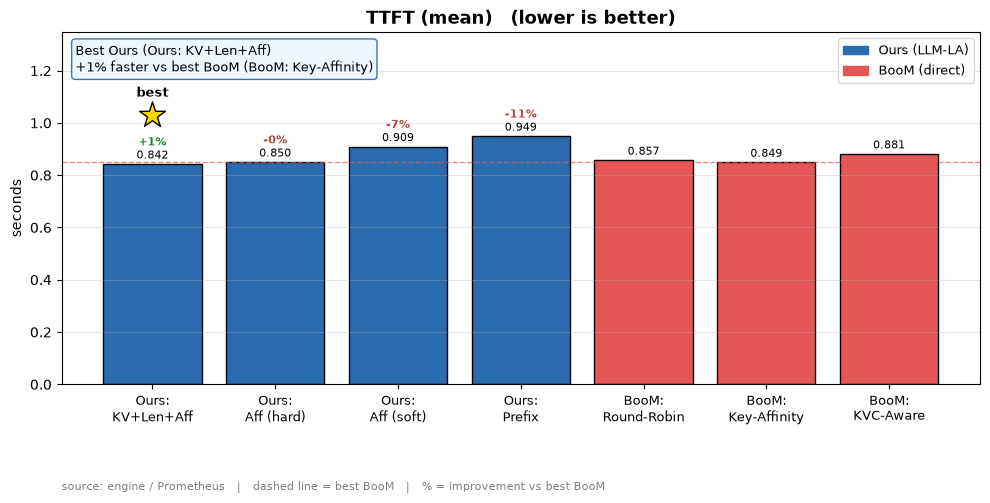

TTFT (mean): best Ours = Ours: KV+Len+Aff (0.842 seconds) vs best BooM = BooM: Key-Affinity (0.849 seconds)  ->  Ours 1.01x lower (+1%)


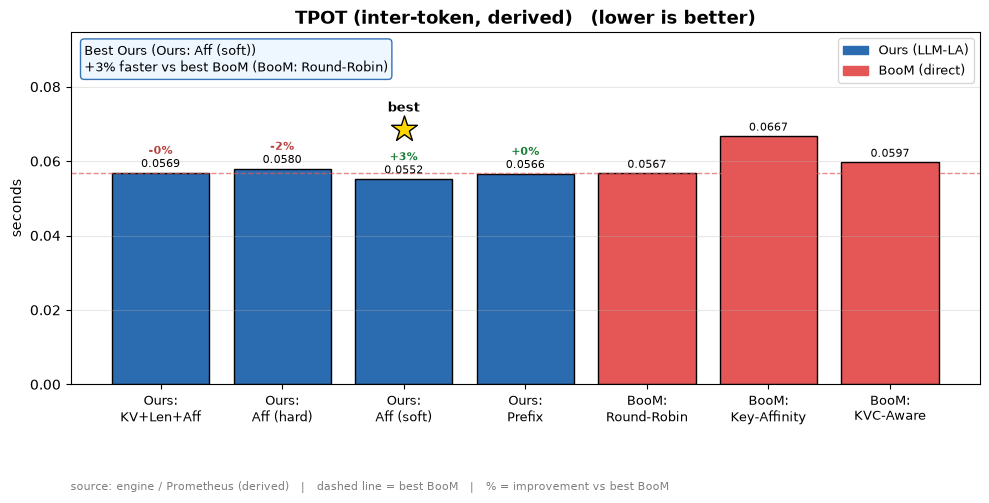

TPOT (inter-token, derived): best Ours = Ours: Aff (soft) (0.0552 seconds) vs best BooM = BooM: Round-Robin (0.0567 seconds)  ->  Ours 1.03x lower (+3%)


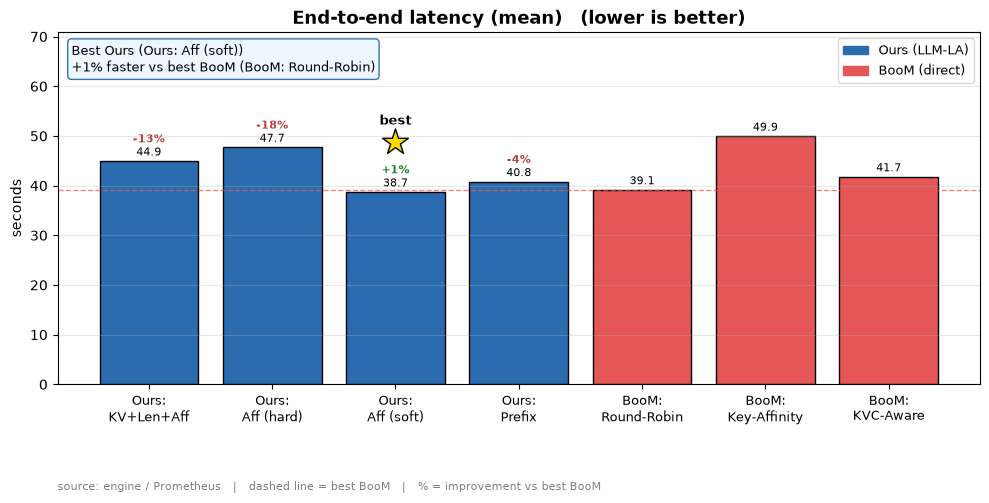

End-to-end latency (mean): best Ours = Ours: Aff (soft) (38.7 seconds) vs best BooM = BooM: Round-Robin (39.1 seconds)  ->  Ours 1.01x lower (+1%)


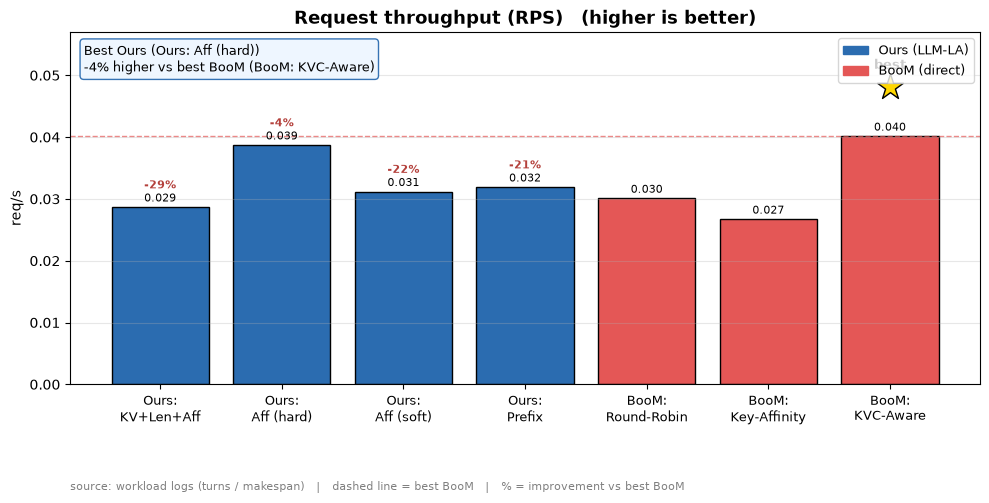

Request throughput (RPS): best Ours = Ours: Aff (hard) (0.039 req/s) vs best BooM = BooM: KVC-Aware (0.040 req/s)  ->  Ours 0.96x higher (-4%)


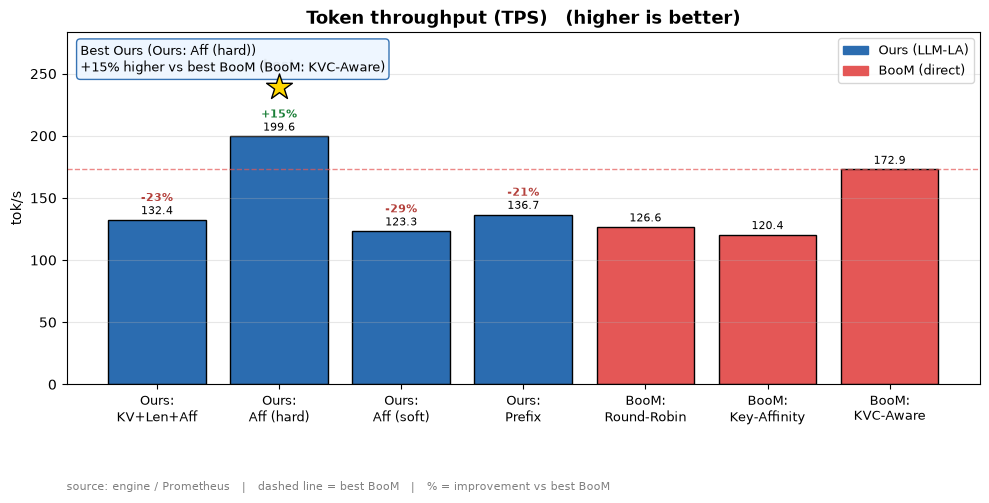

Token throughput (TPS): best Ours = Ours: Aff (hard) (199.6 tok/s) vs best BooM = BooM: KVC-Aware (172.9 tok/s)  ->  Ours 1.15x higher (+15%)


In [15]:
FIG_DIR = Path("/home/saeid/llm-la/analysis-notebooks/figs-u32")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# short, presentation-friendly labels (two lines) + flat Ours/BooM colors
PRES_LABELS = {
    132: "Ours:\nKV+Len+Aff", 133: "Ours:\nAff (hard)",
    134: "Ours:\nAff (soft)",  135: "Ours:\nPrefix",
    136: "BooM:\nRound-Robin", 137: "BooM:\nKey-Affinity", 138: "BooM:\nKVC-Aware",
}
OURS_BLUE, BOOM_RED = "#2b6cb0", "#E45756"
def pres_color(e): return OURS_BLUE if side(e) == "mine" else BOOM_RED
def _1(s):         return PRES_LABELS[s].replace("\n", " ")   # one-line label

def _bfv(e, k):
    v = BF.get(str(e), {}).get(k)
    return float(v) if v is not None else np.nan

# ---- 5 metric series (exp -> value) ----
ttft = {e: _bfv(e, "ttft_avg")        for e in EXP_IDS}
tpot = {e: _bfv(e, "tpot_derived_s")  for e in EXP_IDS}
e2e  = {e: _bfv(e, "e2e_avg")         for e in EXP_IDS}
tps  = {e: _bfv(e, "decode_tok_s")    for e in EXP_IDS}
rps  = {e: (REG.loc[e, "turns"] / REG.loc[e, "load_s"])
             if pd.notna(REG.loc[e, "load_s"]) else np.nan for e in EXP_IDS}

# title, values, unit, higher_better, fmt, source, filename
METRICS = [
    ("TTFT (mean)",                ttft, "seconds", False, "{:.3f}", "engine / Prometheus",                  "p1_ttft.png"),
    ("TPOT (inter-token, derived)", tpot, "seconds", False, "{:.4f}", "engine / Prometheus (derived)",        "p2_tpot.png"),
    ("End-to-end latency (mean)",   e2e,  "seconds", False, "{:.1f}", "engine / Prometheus",                  "p3_e2e.png"),
    ("Request throughput (RPS)",    rps,  "req/s",   True,  "{:.3f}", "workload logs (turns / makespan)",     "p4_rps.png"),
    ("Token throughput (TPS)",      tps,  "tok/s",   True,  "{:.1f}", "engine / Prometheus",                  "p5_tps.png"),
]

def _improve_pct(v, boom_ref, higher_better):
    """% by which value v beats the best-BooM reference (positive = better)."""
    if higher_better:
        return (v / boom_ref - 1) * 100.0
    return (boom_ref / v - 1) * 100.0

def pres_bar(title, vals, unit, higher_better, fmt, source, fname):
    xs = [e for e in EXP_IDS if pd.notna(vals.get(e, np.nan))]
    ys = [vals[e] for e in xs]
    best_i = int(np.argmax(ys) if higher_better else np.argmin(ys))
    ymax = max(ys)

    ours = {e: vals[e] for e in xs if side(e) == "mine"}
    boom = {e: vals[e] for e in xs if side(e) == "boom"}
    bb = (max(boom, key=boom.get) if higher_better else min(boom, key=boom.get)) if boom else None
    bo = (max(ours, key=ours.get) if higher_better else min(ours, key=ours.get)) if ours else None
    boom_ref = boom[bb] if bb is not None else None

    fig, ax = plt.subplots(figsize=(10, 5.3))
    ax.bar(range(len(xs)), ys, color=[pres_color(e) for e in xs], edgecolor="black")
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([PRES_LABELS[e] for e in xs], fontsize=9)
    better = "higher is better" if higher_better else "lower is better"
    ax.set_title(f"{title}   ({better})", fontsize=13, fontweight="bold")
    ax.set_ylabel(unit); ax.grid(axis="y", alpha=.3)

    # dashed reference line at best-BooM level
    if boom_ref is not None:
        ax.axhline(boom_ref, ls="--", lw=1, color=BOOM_RED, alpha=.7, zorder=1)

    for i, (e, v) in enumerate(zip(xs, ys)):
        ax.text(i, v + ymax * 0.012, fmt.format(v), ha="center", va="bottom", fontsize=8)
        # % vs best-BooM printed under each Ours bar (positive = better)
        if side(e) == "mine" and boom_ref:
            d = _improve_pct(v, boom_ref, higher_better)
            ax.text(i, v + ymax * 0.065, f"{d:+.0f}%", ha="center", va="bottom",
                    fontsize=8, fontweight="bold",
                    color=("#1a7f37" if d >= 0 else "#b4413c"))

    # winner star (lifted clear of the value + % labels)
    ax.scatter([best_i], [ys[best_i] + ymax * 0.20], marker="*", s=380,
               color="gold", edgecolor="black", zorder=5)
    ax.text(best_i, ys[best_i] + ymax * 0.26, "best", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    ax.set_ylim(0, ymax * 1.42)

    # headline box: best Ours vs best BooM
    if bo is not None and boom_ref:
        word = "higher" if higher_better else "faster"
        pct = _improve_pct(ours[bo], boom_ref, higher_better)
        ax.text(0.015, 0.97, f"Best Ours ({_1(bo)})\n{pct:+.0f}% {word} vs best BooM ({_1(bb)})",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                bbox=dict(boxstyle="round", fc="#eef6ff", ec=OURS_BLUE, alpha=.95))

    ax.legend(handles=[Patch(color=OURS_BLUE, label="Ours (LLM-LA)"),
                       Patch(color=BOOM_RED,  label="BooM (direct)")],
              fontsize=9, loc="upper right")
    ax.text(0.0, -0.30, f"source: {source}   |   dashed line = best BooM   |   %"
            " = improvement vs best BooM", transform=ax.transAxes,
            fontsize=8, color="gray")
    plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches="tight"); plt.show()

    if bo is not None and boom_ref:
        mult = (ours[bo] / boom_ref) if higher_better else (boom_ref / ours[bo])
        print(f"{title}: best Ours = {_1(bo)} ({fmt.format(ours[bo])} {unit}) "
              f"vs best BooM = {_1(bb)} ({fmt.format(boom_ref)} {unit})  ->  "
              f"Ours {mult:.2f}x {'higher' if higher_better else 'lower'} "
              f"({_improve_pct(ours[bo], boom_ref, higher_better):+.0f}%)")

for spec in METRICS:
    pres_bar(*spec)

In [16]:
# ---- overall winner across the 5 presentation metrics ----
# Normalize each metric so 1.0 = the metric leader (invert for lower-is-better),
# then average the 5 normalized scores per method.
def _norm(vals, higher_better):
    xs = {e: vals[e] for e in EXP_IDS if pd.notna(vals.get(e, np.nan))}
    if not xs:
        return {}
    if higher_better:
        m = max(xs.values()); return {e: xs[e] / m for e in xs}
    m = min(xs.values());     return {e: m / xs[e] for e in xs}

scores = {e: [] for e in EXP_IDS}
for title, vals, unit, hb, fmt, source, fname in METRICS:
    for e, s in _norm(vals, hb).items():
        scores[e].append(s)
avg = {e: float(np.mean(scores[e])) for e in EXP_IDS if scores[e]}

best_ours = max((e for e in avg if side(e) == "mine"), key=lambda e: avg[e])
best_boom = max((e for e in avg if side(e) == "boom"), key=lambda e: avg[e])

print("=== OVERALL (mean normalized score across 5 metrics; 1.0 = metric leader) ===")
for e in sorted(avg, key=lambda e: -avg[e]):
    star = "  <== best Ours" if e == best_ours else ("  <== best BooM" if e == best_boom else "")
    print(f"  {_1(e):22s} {avg[e]:.3f}  [{side(e)}]{star}")

gap = (avg[best_ours] / avg[best_boom] - 1) * 100
print(f"\nHEADLINE: best Ours = {_1(best_ours)} (score {avg[best_ours]:.3f}) "
      f"beats best BooM = {_1(best_boom)} (score {avg[best_boom]:.3f}) "
      f"by {gap:.0f}% overall across TTFT / TPOT / E2E / RPS / TPS.")

=== OVERALL (mean normalized score across 5 metrics; 1.0 = metric leader) ===
  Ours: Aff (hard)       0.944  [mine]  <== best Ours
  BooM: KVC-Aware        0.935  [boom]  <== best BooM
  BooM: Round-Robin      0.866  [boom]
  Ours: Aff (soft)       0.864  [mine]
  Ours: Prefix           0.858  [mine]
  Ours: KV+Len+Aff       0.842  [mine]
  BooM: Key-Affinity     0.773  [boom]

HEADLINE: best Ours = Ours: Aff (hard) (score 0.944) beats best BooM = BooM: KVC-Aware (score 0.935) by 1% overall across TTFT / TPOT / E2E / RPS / TPS.


### 9b. Summary / tradeoff / distribution views

Four more presentation views, all colored **Ours (blue) vs BooM (red)** and all
expressed relative to the **best BooM** method:

- **Overall ranking** - mean normalized score across the 5 metrics, each bar labeled with its **% vs best BooM**.
- **Latency-throughput tradeoff** - E2E-mean (x, lower better) vs TPS (y, higher better); up-and-left dominates (Pareto).
- **Radar** - best Ours vs best BooM across all 5 normalized axes (1.0 = metric leader).
- **E2E latency violin** - full per-turn distribution shape per method (complements the p50/mean bars).

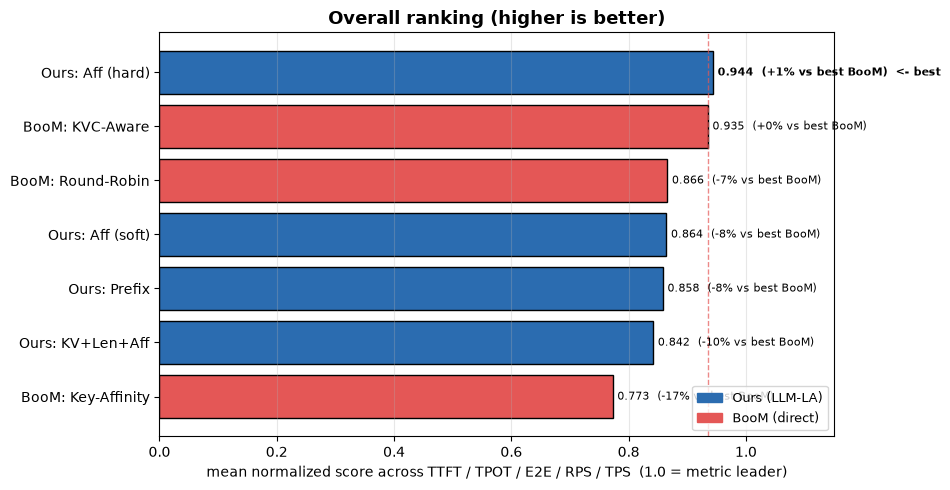

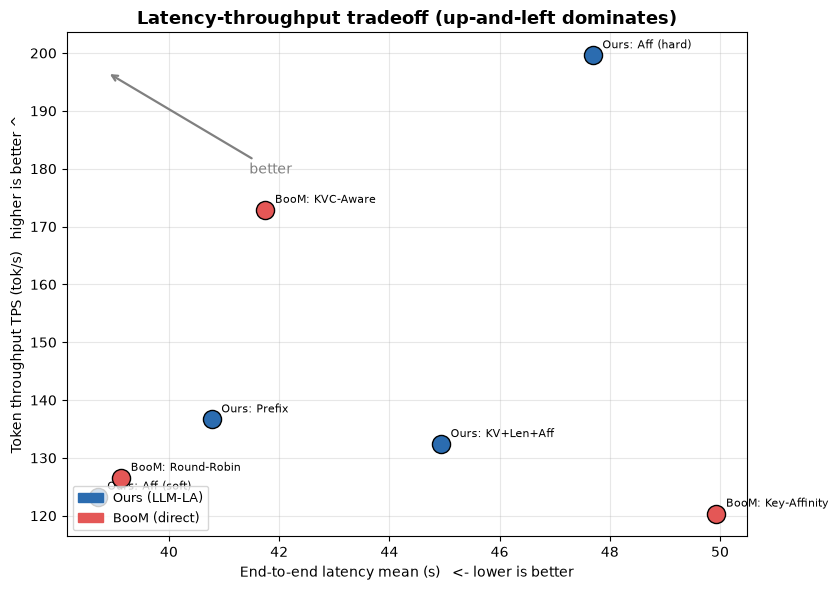

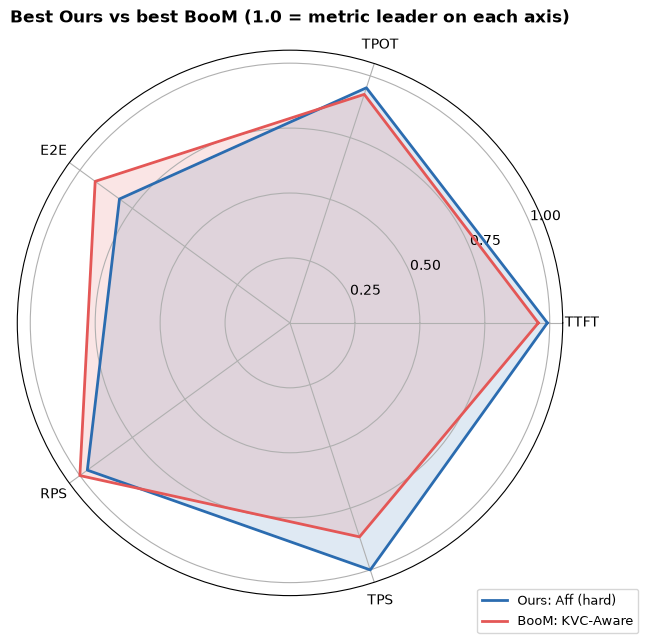

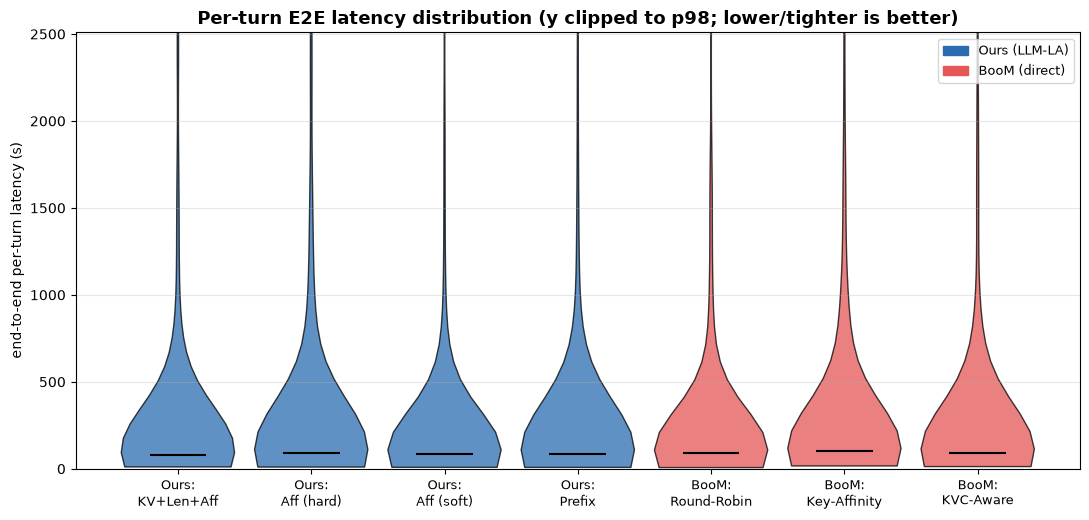

In [17]:
# ============ 9b-1. Overall ranking (mean normalized score) ============
order = sorted(avg, key=lambda e: avg[e])          # ascending -> best on top in barh
boom_score = avg[best_boom]
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh([_1(e) for e in order], [avg[e] for e in order],
        color=[pres_color(e) for e in order], edgecolor="black")
ax.axvline(boom_score, ls="--", lw=1, color=BOOM_RED, alpha=.7)
for i, e in enumerate(order):
    d = (avg[e] / boom_score - 1) * 100
    tag = "  <- best" if e == best_ours else ""
    ax.text(avg[e] + 0.008, i, f"{avg[e]:.3f}  ({d:+.0f}% vs best BooM){tag}",
            va="center", fontsize=8,
            fontweight=("bold" if e == best_ours else "normal"))
ax.set_xlim(0, 1.15)
ax.set_xlabel("mean normalized score across TTFT / TPOT / E2E / RPS / TPS  (1.0 = metric leader)")
ax.set_title("Overall ranking (higher is better)", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=.3)
ax.legend(handles=[Patch(color=OURS_BLUE, label="Ours (LLM-LA)"),
                   Patch(color=BOOM_RED,  label="BooM (direct)")], fontsize=9, loc="lower right")
plt.tight_layout(); plt.savefig(FIG_DIR / "p6_ranking.png", dpi=130, bbox_inches="tight"); plt.show()

# ============ 9b-2. Latency-throughput tradeoff (Pareto) ============
fig, ax = plt.subplots(figsize=(8.5, 6))
for e in EXP_IDS:
    x, y = e2e[e], tps[e]
    if pd.isna(x) or pd.isna(y):
        continue
    ax.scatter(x, y, color=pres_color(e), s=170, edgecolor="black", zorder=3)
    ax.annotate(_1(e), (x, y), textcoords="offset points", xytext=(7, 5), fontsize=8)
ax.set_xlabel("End-to-end latency mean (s)   <- lower is better")
ax.set_ylabel("Token throughput TPS (tok/s)   higher is better ^")
ax.set_title("Latency-throughput tradeoff (up-and-left dominates)", fontsize=13, fontweight="bold")
ax.grid(alpha=.3)
# 'better' direction arrow (toward up-left)
xr = ax.get_xlim(); yr = ax.get_ylim()
ax.annotate("better", xy=(xr[0] + 0.06*(xr[1]-xr[0]), yr[1] - 0.08*(yr[1]-yr[0])),
            xytext=(xr[0] + 0.30*(xr[1]-xr[0]), yr[1] - 0.28*(yr[1]-yr[0])),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.6),
            fontsize=10, color="gray", ha="center")
ax.legend(handles=[Patch(color=OURS_BLUE, label="Ours (LLM-LA)"),
                   Patch(color=BOOM_RED,  label="BooM (direct)")], fontsize=9, loc="lower left")
plt.tight_layout(); plt.savefig(FIG_DIR / "p7_tradeoff.png", dpi=130, bbox_inches="tight"); plt.show()

# ============ 9b-3. Radar: best Ours vs best BooM ============
radar_axes = ["TTFT", "TPOT", "E2E", "RPS", "TPS"]
norm_by_metric = [_norm(vals, hb) for (t, vals, u, hb, f, s, fn) in METRICS]
def _radar(e): return [nm.get(e, np.nan) for nm in norm_by_metric]
ang = np.linspace(0, 2*np.pi, len(radar_axes), endpoint=False).tolist(); ang += ang[:1]
fig = plt.figure(figsize=(6.5, 6.5)); ax = plt.subplot(111, polar=True)
for e, c in [(best_ours, OURS_BLUE), (best_boom, BOOM_RED)]:
    v = _radar(e); v = v + v[:1]
    ax.plot(ang, v, color=c, lw=2, label=_1(e))
    ax.fill(ang, v, color=c, alpha=.15)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar_axes, fontsize=10)
ax.set_ylim(0, 1.05); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title("Best Ours vs best BooM (1.0 = metric leader on each axis)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.08), fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "p8_radar.png", dpi=130, bbox_inches="tight"); plt.show()

# ============ 9b-4. E2E per-turn latency violin (distribution) ============
fig, ax = plt.subplots(figsize=(11, 5.3))
data = [TURNS[TURNS["exp"] == e]["end_to_end_s"].dropna().values for e in EXP_IDS]
clip = np.nanpercentile(np.concatenate([d for d in data if len(d)]), 98)
parts = ax.violinplot(data, showmedians=True, showextrema=False, widths=0.85)
for pc, e in zip(parts["bodies"], EXP_IDS):
    pc.set_facecolor(pres_color(e)); pc.set_edgecolor("black"); pc.set_alpha(.75)
if "cmedians" in parts:
    parts["cmedians"].set_color("black")
ax.set_xticks(range(1, len(EXP_IDS)+1))
ax.set_xticklabels([PRES_LABELS[e] for e in EXP_IDS], fontsize=9)
ax.set_ylim(0, clip); ax.set_ylabel("end-to-end per-turn latency (s)")
ax.set_title("Per-turn E2E latency distribution (y clipped to p98; lower/tighter is better)",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=.3)
ax.legend(handles=[Patch(color=OURS_BLUE, label="Ours (LLM-LA)"),
                   Patch(color=BOOM_RED,  label="BooM (direct)")], fontsize=9, loc="upper right")
plt.tight_layout(); plt.savefig(FIG_DIR / "p9_e2e_violin.png", dpi=130, bbox_inches="tight"); plt.show()